In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import glob 
import re


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Tests run at:
- 10 V Floating Potential + 1.7 V Heating Potential (0.98A)
- 0.0 V DC In/Ap2
- -3.0 V Spacers
- -6.0 V DC Out/Ap3
- $\approx 1.3E-5$ Gauge
- -2400 V Detector Bias


In [3]:
def parse_rf_filename(filepath):
    basename = filepath.split("/")[-1]
    match = re.match(r"RF(\d+)_(\d+)(?:_(\d+))?\.mpa$", basename)
    if match is None:
        return None
    vpp = int(match.group(1))
    freq_khz = int(match.group(2))
    run = int(match.group(3)) if match.group(3) else 1
    return vpp, freq_khz, run

def read_mpa_file(filepath):
    realtime = None
    totalsum = None
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())
    return realtime, totalsum

def get_rate_and_uncertainty(filepath):
    realtime, totalsum = read_mpa_file(filepath)
    if realtime is None or totalsum is None:
        print(f"WARNING: couldn't parse REALTIME/TOTALSUM from {filepath}, skipping")
        return None, None
    rate = totalsum / realtime
    rate_unc = np.sqrt(totalsum) / realtime
    return rate, rate_unc

rf_files = [f for f in glob.glob("RFPCB/RF*.mpa") if "Noise" not in f]

rf_runs = []
for filepath in rf_files:
    parsed = parse_rf_filename(filepath)
    if parsed is None:
        continue
    vpp, freq_khz, run = parsed
    rf_runs.append({"filepath": filepath, "vpp": vpp, "freq_khz": freq_khz, "run": run})

rf_runs_df = pd.DataFrame(rf_runs).sort_values(["freq_khz", "vpp", "run"]).reset_index(drop=True)

rf_runs_df["rate_hz"], rf_runs_df["rate_unc_hz"] = zip(
    *rf_runs_df["filepath"].apply(get_rate_and_uncertainty)
)

In [4]:
potassium_mass = 39.0983  # g/mol
rubidium_mass = 85.4678  # g/mol
cesium_mass = 132.90545  # g/mol

e = 1.602176634e-19  # elementary charge in Coulombs
u = 1.66053906660e-27  # atomic mass unit in kg

r_0 = 1/2*np.sqrt((0.5 * (6.60 + 6.55))**2 + (0.5 * (6.60 + 6.72))**2) * 1.08
print(r_0)

5.053725676171987


In [5]:
run1_df = rf_runs_df[rf_runs_df["run"] == 1].copy()

In [6]:
def q_val(m, f, r, vpp):
    m_kg = m * u  # convert mass from g/mol to kg
    V0 = vpp / 2  # peak voltage in volts
    omega = 2 * np.pi * f * 1e3  # angular frequency in rad/s
    r_0_m = r/1000  # convert r from mm to meters
    q = 4 * e * V0 / (m_kg * omega**2 * r_0_m**2)
    return q


In [7]:
species = {
    "Cesium": cesium_mass,
    "Rubidium": rubidium_mass,
    "Potassium": potassium_mass
}

q_tables = {}

for name, mass in species.items():
    table = rf_runs_df[["freq_khz", "vpp"]].copy()
    table['q'] = rf_runs_df.apply(lambda row: q_val(mass, row['freq_khz'], r_0, row['vpp']), axis=1)
    table = table.sort_values(["freq_khz", "vpp"]).reset_index(drop=True)
    q_tables[name] = table

def make_titled_table(name, mass, rf_runs_df, r_0):
    table = rf_runs_df[["freq_khz", "vpp"]].copy()
    table["q"] = rf_runs_df.apply(
        lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]),
        axis=1
    )
    table = table.sort_values(["freq_khz", "vpp"]).reset_index(drop=True)

    # Build a two-level column header: top level is the title, spans all columns
    table.columns = pd.MultiIndex.from_product([[f"{name} q-values"], table.columns])
    return table

cesium_table = make_titled_table("Cesium", cesium_mass, rf_runs_df, r_0).style.hide(axis="index")
potassium_table = make_titled_table("Potassium", potassium_mass, rf_runs_df, r_0).style.hide(axis="index")
rubidium_table = make_titled_table("Rubidium", rubidium_mass, rf_runs_df, r_0).style.hide(axis="index")

run_config = {
    1: {"label": "Baseline Original", "float_v": 10, "delta_v": 6},
    2: {"label": "Original (Injection = 10V, ΔV =6V)", "float_v": 10, "delta_v": 6},
    3: {"label": "Lower DC Gradient (ΔV = 3)", "float_v": 10, "delta_v": 3},
    4: {"label": "Lower Injection Energy (V = 5V)", "float_v": 5, "delta_v": 6},
    5: {"label": "Lower Injection and DC Gradient", "float_v": 5, "delta_v": 3},
    6: {"label": "Higher Injection Energy (V = 15V)", "float_v": 15, "delta_v": 6},
    7: {"label": "Test: Injection=10V (ΔV=6V)", "float_v": 20, "delta_v": 6},
    8: {"label": "Test2: Injection=10V (ΔV=6V)", "float_v": 10, "delta_v": 6},
    9: {"label": "Resonant Frequency Test, Injection=10V (ΔV=6V)", "float_v": 10, "delta_v": 6},
    10:{"label": "Final Test 725 KHz (Injection = 10V, ΔV = 6V)", "float_v": 10, "delta_v": 6},
    11:{"label": "Final Test 1127 KHz (Injection = 10V, ΔV = 6V)", "float_v": 10, "delta_v": 6},
    12:{"label": "DC On 1144 kHz (Injection = 10V, ΔV = 10V)", "float_v": 10, "delta_v": 10},
    13:{"label": "DC Off 1144 kHz (Injection = 10V, ΔV = 0V)", "float_v": 10, "delta_v":0},
}

rf_runs_df["config_label"] = rf_runs_df["run"].map(lambda r: run_config[r]["label"])

In [8]:
run1_df = rf_runs_df[rf_runs_df["run"] == 1].copy()

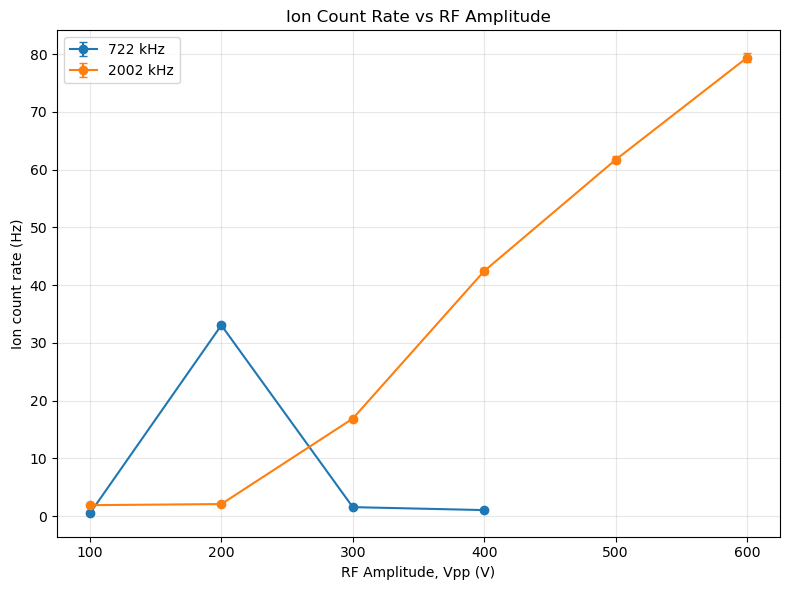

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for freq_khz, group in run1_df.groupby("freq_khz"):
    group = group.sort_values("vpp")
    ax.errorbar(
        group["vpp"], group["rate_hz"], yerr=group["rate_unc_hz"],
        marker="o", capsize=3, label=f"{freq_khz} kHz"
    )


#ax.set_yscale("log")
ax.set_xlabel("RF Amplitude, Vpp (V)")
ax.set_ylabel("Ion count rate (Hz)")
ax.set_title("Ion Count Rate vs RF Amplitude")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
def plot_species(ax, name, mass, data_df, r_0, draw_span=True, vpp_frac_err=0.125):
    plot_df = data_df[["freq_khz", "vpp", "rate_hz", "rate_unc_hz"]].copy()
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]),
        axis=1
    )

    if draw_span:
        ax.axvspan(0.4, 0.8, color='lightcoral', alpha=0.1)

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for i, (freq_khz, group) in enumerate(plot_df.groupby("freq_khz")):
        group = group.sort_values("q")
        q_xerr = group["q"] * vpp_frac_err
        color = colors[i % len(colors)]
        faded_color = mcolors.to_rgba(color, alpha=0.3)

        ax.errorbar(
            group["q"], group["rate_hz"], yerr=group["rate_unc_hz"], xerr=q_xerr,
            marker="o", capsize=3, color=color, ecolor=faded_color,
            label=f"{freq_khz} kHz"
        )

    ax.set_xlabel("Q-value", fontsize=16)
    ax.set_title(name, fontsize=18)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

In [11]:
# Run two, more refined search of 722 KHz test:

v_in = [1.2, 1.4, 1.6, 2.5, 2.8, 3.0, 3.2, 3.4, 3.6, 3.9, 4.2]

In [12]:
run2_df = rf_runs_df[(rf_runs_df["run"] == 2)].copy()
run2_df

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz,config_label
20,RFPCB/RF100_722_2.mpa,100,722,2,1.092940,0.085344,"Original (Injection = 10V, ΔV =6V)"
29,RFPCB/RF114_722_2.mpa,114,722,2,2.143566,0.119456,"Original (Injection = 10V, ΔV =6V)"
37,RFPCB/RF128_722_2.mpa,128,722,2,30.848860,0.453317,"Original (Injection = 10V, ΔV =6V)"
45,RFPCB/RF148_722_2.mpa,148,722,2,36.881917,0.495562,"Original (Injection = 10V, ΔV =6V)"
49,RFPCB/RF164_722_2.mpa,164,722,2,41.530076,0.526034,"Original (Injection = 10V, ΔV =6V)"
55,RFPCB/RF186_722_2.mpa,186,722,2,45.365798,0.549818,"Original (Injection = 10V, ΔV =6V)"
61,RFPCB/RF200_722_2.mpa,200,722,2,42.514615,0.532348,"Original (Injection = 10V, ΔV =6V)"
69,RFPCB/RF224_722_2.mpa,224,722,2,38.920879,0.509303,"Original (Injection = 10V, ΔV =6V)"
75,RFPCB/RF240_722_2.mpa,240,722,2,20.562727,0.370094,"Original (Injection = 10V, ΔV =6V)"
80,RFPCB/RF260_722_2.mpa,260,722,2,2.450197,0.127725,"Original (Injection = 10V, ΔV =6V)"


In [13]:
run1_df_2002 = rf_runs_df[(rf_runs_df["run"] == 1) & (rf_runs_df["freq_khz"] == 2002)].copy()

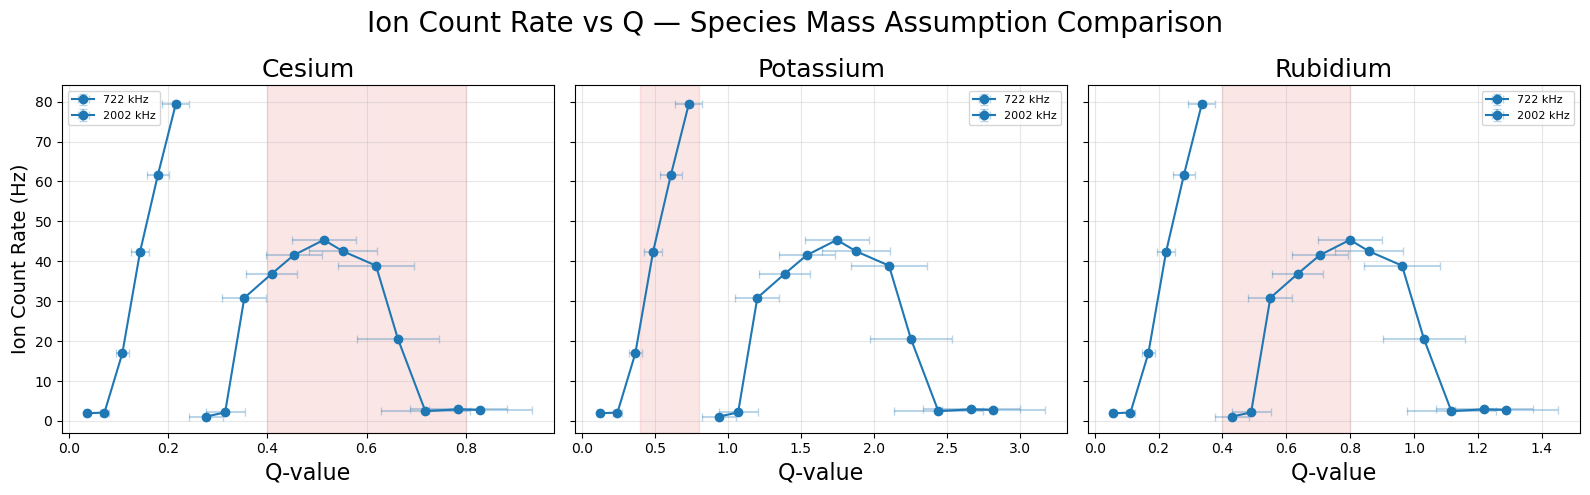

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

plot_species(axes[0], "Cesium", cesium_mass, run2_df, r_0)
plot_species(axes[1], "Potassium", potassium_mass, run2_df, r_0)
plot_species(axes[2], "Rubidium", rubidium_mass, run2_df, r_0)
plot_species(axes[0], "Cesium", cesium_mass, run1_df_2002, r_0)
plot_species(axes[1], "Potassium", potassium_mass, run1_df_2002, r_0)
plot_species(axes[2], "Rubidium", rubidium_mass, run1_df_2002, r_0)

axes[0].set_ylabel("Ion Count Rate (Hz)", fontsize=14)
fig.suptitle("Ion Count Rate vs Q — Species Mass Assumption Comparison", fontsize = 20)
plt.tight_layout()
plt.show()

In [15]:
def compute_resolving_power_combined(mass, run_df, r_0, freq_khz=722, 
                                       vpp_frac_err=0.125, n_trials=2000, seed=64):
    """
    Combines two distinct uncertainty sources:
    - Systematic: Vpp probe/divider error, treated as a fixed calibration offset,
      evaluated at nominal/low/high scale (NOT randomly drawn)
    - Statistical: TDC count-rate Poisson/SEM uncertainty, propagated via Monte Carlo
    """
    rng = np.random.default_rng(seed)

    df = run_df[run_df["freq_khz"] == freq_khz].copy().reset_index(drop=True)
    vpp_arr = df["vpp"].values.astype(float)
    rate_arr_nominal = df["rate_hz"].values
    rate_unc_arr = df["rate_unc_hz"].values

    def _mc_at_vpp_scale(scale):
        """Run the rate-only Monte Carlo at a fixed, scaled Vpp axis."""
        scaled_vpp = vpp_arr * scale
        q_arr = np.array([q_val(mass, freq_khz, r_0, v) for v in scaled_vpp])
        order = np.argsort(q_arr)
        q_sorted = q_arr[order]
        rate_nominal_sorted = rate_arr_nominal[order]
        rate_unc_sorted = rate_unc_arr[order]

        resolving_powers = []
        for _ in range(n_trials):
            sampled_rate = rng.normal(rate_nominal_sorted, rate_unc_sorted)
            sampled_rate = np.clip(sampled_rate, 0, None)

            peak_idx = np.argmax(sampled_rate)
            q_peak = q_sorted[peak_idx]
            half_max = sampled_rate[peak_idx] / 2

            rising_q, rising_rate = q_sorted[:peak_idx+1], sampled_rate[:peak_idx+1]
            falling_q, falling_rate = q_sorted[peak_idx:], sampled_rate[peak_idx:]

            try:
                q_left = np.interp(half_max, rising_rate, rising_q)
                q_right = np.interp(half_max, falling_rate[::-1], falling_q[::-1])
                fwhm_q = q_right - q_left
                if fwhm_q > 0 and q_peak > 0:
                    resolving_powers.append(mass / ((fwhm_q / q_peak) * mass))
            except Exception:
                continue

        resolving_powers = np.array(resolving_powers)
        return {
            "mean": np.mean(resolving_powers) if len(resolving_powers) else np.nan,
            "std": np.std(resolving_powers) if len(resolving_powers) else np.nan,
            "n_valid": len(resolving_powers),
        }

    nominal_result = _mc_at_vpp_scale(1.0)
    low_result = _mc_at_vpp_scale(1.0 - vpp_frac_err)
    high_result = _mc_at_vpp_scale(1.0 + vpp_frac_err)

    systematic_values = [low_result["mean"], nominal_result["mean"], high_result["mean"]]
    systematic_min = min(systematic_values)
    systematic_max = max(systematic_values)

    return {
        "resolving_power": nominal_result["mean"],
        "stat_err": nominal_result["std"],
        "syst_min": systematic_min,
        "syst_max": systematic_max,
        "n_valid_trials": nominal_result["n_valid"],
        "n_total_trials": n_trials,
    }

In [16]:
runs_to_compare = [2, 3, 4, 5, 6, 7, 8]  # excludes original crude baseline (run 1)

summary_rows = []
for run_num in runs_to_compare:
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    if run_df.empty:
        continue
    meta = run_config[run_num]
    n_points = len(run_df[run_df["freq_khz"] == 722])
    result = compute_resolving_power_combined(
        rubidium_mass, run_df, r_0, freq_khz=722, vpp_frac_err=0.125, n_trials=2000, seed=42
    )
    summary_rows.append({
        "run": run_num,
        "config": meta["label"],
        "n_points": n_points,
        "resolving_power": result["resolving_power"],
        "stat_err": result["stat_err"],
        "syst_min": result["syst_min"],
        "syst_max": result["syst_max"],
    })


summary_df = pd.DataFrame(summary_rows)
summary_df

,run,config,n_points,resolving_power,stat_err,syst_min,syst_max
0,2,"Original (Injection = 10V, ΔV =6V)",12,1.629891,0.007124,1.629756,1.629891
1,3,Lower DC Gradient (ΔV = 3),18,0.970350,0.018637,0.970174,0.970515
2,4,Lower Injection Energy (V = 5V),16,1.486975,0.134271,1.486975,1.491222
3,5,Lower Injection and DC Gradient,18,1.005752,0.203921,1.005752,1.007672
4,6,Higher Injection Energy (V = 15V),20,1.560182,0.021940,1.560182,1.560982
5,7,Test: Injection=10V (ΔV=6V),4,5.943952,0.004821,5.943762,5.943952
6,8,Test2: Injection=10V (ΔV=6V),5,3.727532,0.014719,3.727528,3.727532


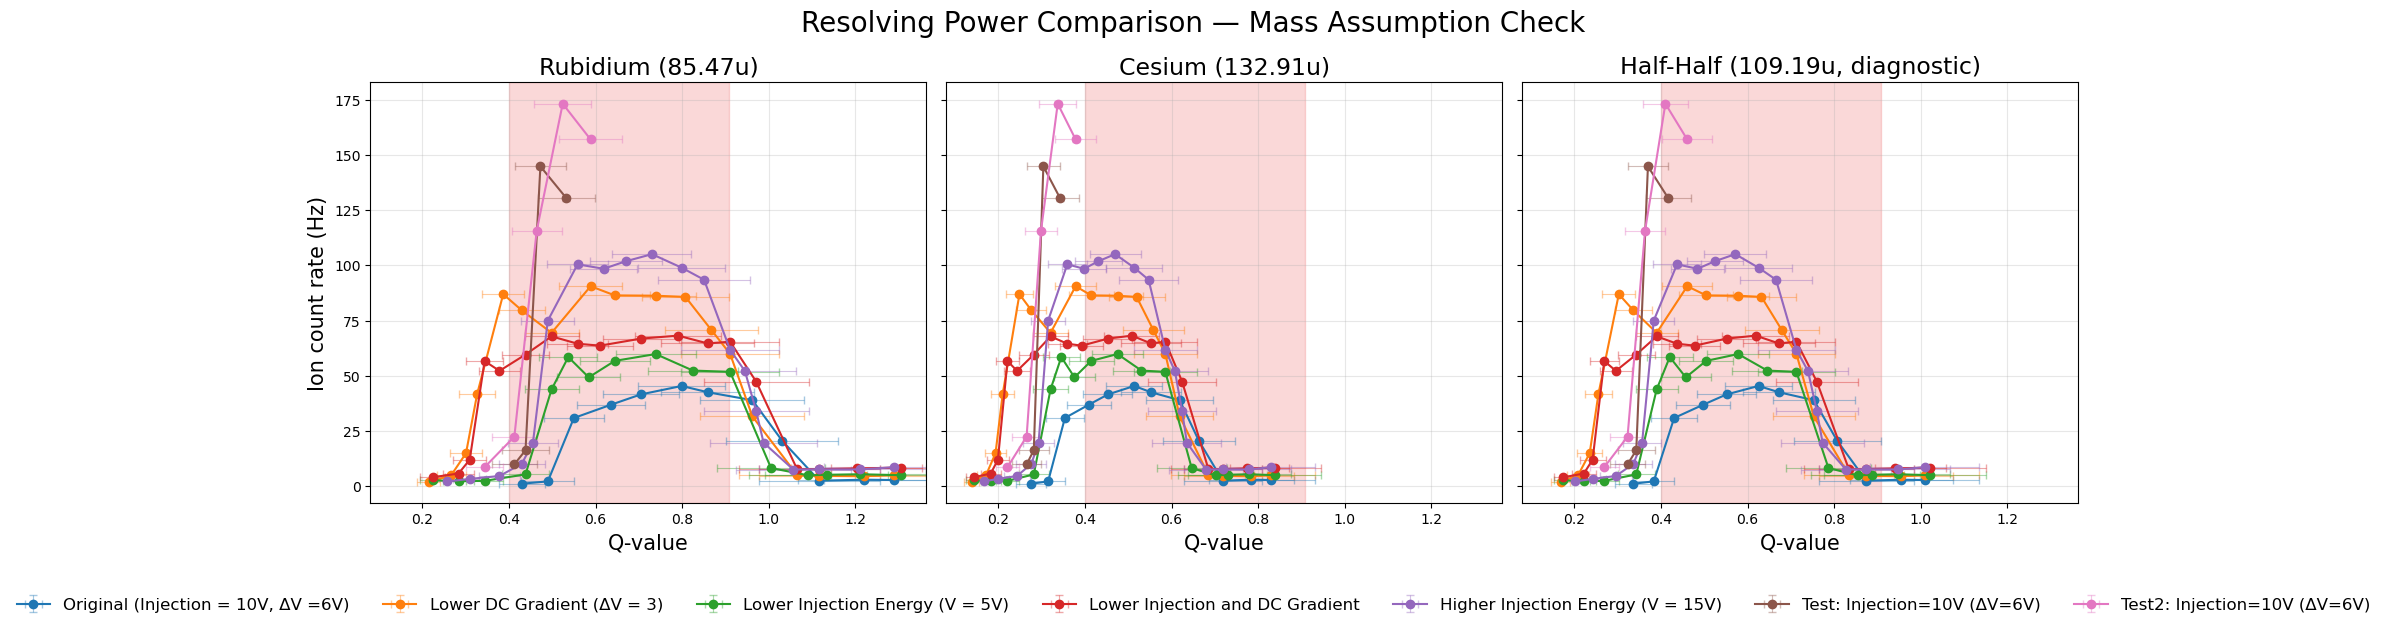

In [17]:
vpp_frac_err = 0.125  # 12.5% probe/divider error, same value used in compute_resolving_power_combined

mixed_mass = (rubidium_mass + cesium_mass) / 2

mass_panels = {
    "Rubidium (85.47u)": rubidium_mass,
    "Cesium (132.91u)": cesium_mass,
    "Half-Half (109.19u, diagnostic)": mixed_mass,
}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # fixed color per run, reused across panels

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

all_q_values = []
for panel_name, mass in mass_panels.items():
    for run_num in runs_to_compare:
        run_df = rf_runs_df[rf_runs_df["run"] == run_num]
        if run_df.empty:
            continue
        plot_df = run_df[run_df["freq_khz"] == 722].copy()
        q_vals = plot_df.apply(lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]), axis=1)
        all_q_values.extend(q_vals.tolist())

q_min, q_max = min(all_q_values), max(all_q_values)
q_pad = (q_max - q_min) * 0.05

for ax, (panel_name, mass) in zip(axes, mass_panels.items()):
    ax.axvspan(0.4, 0.908, color='lightcoral', alpha=0.3)
    for i, run_num in enumerate(runs_to_compare):
        run_df = rf_runs_df[rf_runs_df["run"] == run_num]
        if run_df.empty:
            continue
        meta = run_config[run_num]
        plot_df = run_df[run_df["freq_khz"] == 722].copy()
        plot_df["q"] = plot_df.apply(lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]), axis=1)
        plot_df = plot_df.sort_values("q")

        q_xerr = plot_df["q"] * vpp_frac_err
        color = colors[i % len(colors)]
        faded_color = mcolors.to_rgba(color, alpha=0.4)

        ax.errorbar(plot_df["q"], plot_df["rate_hz"],
                    yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
                    marker="o", capsize=3, label=meta["label"],
                    color=color, ecolor=faded_color, elinewidth=0.8)

    ax.set_xlim(q_min - q_pad, q_max + q_pad)
    ax.set_xlabel("Q-value", fontsize=15)
    ax.set_title(panel_name, fontsize=17)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Ion count rate (Hz)", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=len(labels), fontsize=12, frameon=False)

fig.suptitle("Resolving Power Comparison — Mass Assumption Check", fontsize=20)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

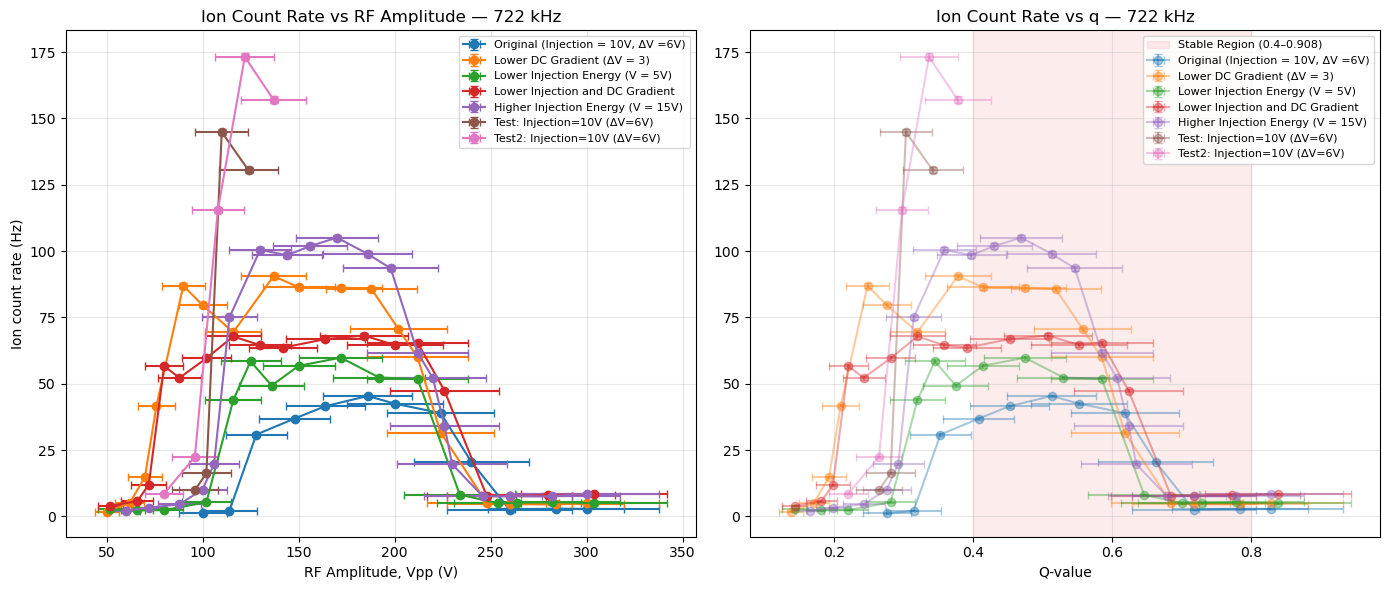

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

vpp_frac_err = 0.125  # established probe/divider systematic error

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(14, 6))

# --- Left panel: Ion Count Rate vs Vpp ---
plt.subplot(1, 2, 1)
for i, run_num in enumerate(runs_to_compare):  # excludes run 1
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == 722].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values("vpp")
    meta = run_config[run_num]
    color = colors[i % len(colors)]

    vpp_xerr = plot_df["vpp"] * vpp_frac_err

    plt.errorbar(
        plot_df["vpp"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=vpp_xerr,
        marker="o", capsize=3, color=color, label=meta["label"]
    )
plt.xlabel("RF Amplitude, Vpp (V)")
plt.ylabel("Ion count rate (Hz)")
plt.title("Ion Count Rate vs RF Amplitude — 722 kHz")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)

# --- Right panel: Ion Count Rate vs q-value (Cesium), with stability band ---
plt.subplot(1, 2, 2)
plt.axvspan(0.4, 0.8, color='lightcoral', alpha=0.15, label='Stable Region (0.4–0.908)')

for i, run_num in enumerate(runs_to_compare):
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == 722].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    meta = run_config[run_num]
    color = colors[i % len(colors)]

    q_xerr = plot_df["q"] * vpp_frac_err  # same fractional error propagated into q
    faded_color = mcolors.to_rgba(color, alpha=0.4)

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=faded_color, label=meta["label"]
    )
plt.xlabel("Q-value")
plt.title("Ion Count Rate vs q — 722 kHz")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
run10 = rf_runs_df[rf_runs_df["run"] == 10].copy()
run10

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz,config_label
97,RFPCB/RF50_725_10.mpa,50,725,10,2.998098,0.172807,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
98,RFPCB/RF61_725_10.mpa,61,725,10,3.995775,0.199539,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
99,RFPCB/RF78_725_10.mpa,78,725,10,4.654222,0.215372,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
100,RFPCB/RF92_725_10.mpa,92,725,10,6.543510,0.255481,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
101,RFPCB/RF100_725_10.mpa,100,725,10,7.654767,0.276398,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
102,RFPCB/RF106_725_10.mpa,106,725,10,44.385330,0.664991,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
103,RFPCB/RF114_725_10.mpa,114,725,10,106.446792,1.029878,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
104,RFPCB/RF122_725_10.mpa,122,725,10,98.170032,0.989448,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
105,RFPCB/RF131_725_10.mpa,131,725,10,106.601818,1.030751,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"
106,RFPCB/RF141_725_10.mpa,141,725,10,126.776283,1.123984,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)"


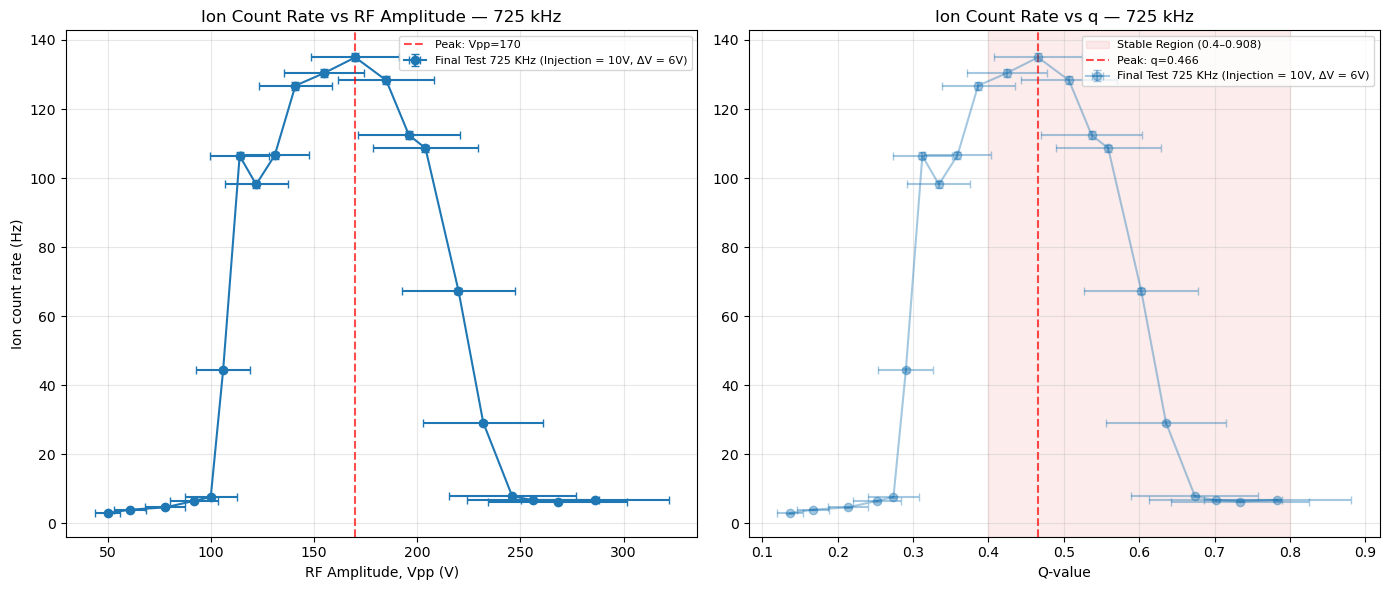

In [20]:
vpp_frac_err = 0.125  # established probe/divider systematic error

runs_to_compare = [10]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Find peak for run 10 (cesium assumption) to annotate on both panels
run10_df = rf_runs_df[(rf_runs_df["run"] == 10) & (rf_runs_df["freq_khz"] == 725)].copy()
run10_df["q"] = run10_df.apply(
    lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
)
peak_row = run10_df.loc[run10_df["rate_hz"].idxmax()]
vpp_peak = peak_row["vpp"]
q_peak = peak_row["q"]

plt.figure(figsize=(14, 6))

# --- Left panel: Ion Count Rate vs Vpp ---
plt.subplot(1, 2, 1)
for i, run_num in enumerate(runs_to_compare):
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == 725].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values("vpp")
    meta = run_config[run_num]
    color = colors[i % len(colors)]

    vpp_xerr = plot_df["vpp"] * vpp_frac_err

    plt.errorbar(
        plot_df["vpp"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=vpp_xerr,
        marker="o", capsize=3, color=color, label=meta["label"]
    )

plt.axvline(vpp_peak, color="red", linestyle="--", alpha=0.7, label=f"Peak: Vpp={vpp_peak}")
plt.xlabel("RF Amplitude, Vpp (V)")
plt.ylabel("Ion count rate (Hz)")
plt.title("Ion Count Rate vs RF Amplitude — 725 kHz")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)

# --- Right panel: Ion Count Rate vs q-value (Cesium), with stability band ---
plt.subplot(1, 2, 2)
plt.axvspan(0.4, 0.8, color='lightcoral', alpha=0.15, label='Stable Region (0.4–0.908)')

for i, run_num in enumerate(runs_to_compare):
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == 725].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    meta = run_config[run_num]
    color = colors[i % len(colors)]

    q_xerr = plot_df["q"] * vpp_frac_err
    faded_color = mcolors.to_rgba(color, alpha=0.4)

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=faded_color, label=meta["label"]
    )

plt.axvline(q_peak, color="red", linestyle="--", alpha=0.7, label=f"Peak: q={q_peak:.3f}")
plt.xlabel("Q-value")
plt.title("Ion Count Rate vs q — 725 kHz")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
run10_df = rf_runs_df[rf_runs_df["run"] == 10].copy()
run10_df["q"] = run10_df.apply(
    lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
)

peak_row = run10_df.loc[run10_df["rate_hz"].idxmax()]
q_peak = peak_row["q"]
vpp_peak = peak_row["vpp"]
rate_peak = peak_row["rate_hz"]

run10_df

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz,config_label,q
97,RFPCB/RF50_725_10.mpa,50,725,10,2.998098,0.172807,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.136981
98,RFPCB/RF61_725_10.mpa,61,725,10,3.995775,0.199539,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.167116
99,RFPCB/RF78_725_10.mpa,78,725,10,4.654222,0.215372,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.213690
100,RFPCB/RF92_725_10.mpa,92,725,10,6.543510,0.255481,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.252045
101,RFPCB/RF100_725_10.mpa,100,725,10,7.654767,0.276398,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.273961
102,RFPCB/RF106_725_10.mpa,106,725,10,44.385330,0.664991,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.290399
103,RFPCB/RF114_725_10.mpa,114,725,10,106.446792,1.029878,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.312316
104,RFPCB/RF122_725_10.mpa,122,725,10,98.170032,0.989448,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.334233
105,RFPCB/RF131_725_10.mpa,131,725,10,106.601818,1.030751,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.358889
106,RFPCB/RF141_725_10.mpa,141,725,10,126.776283,1.123984,"Final Test 725 KHz (Injection = 10V, ΔV = 6V)",0.386286


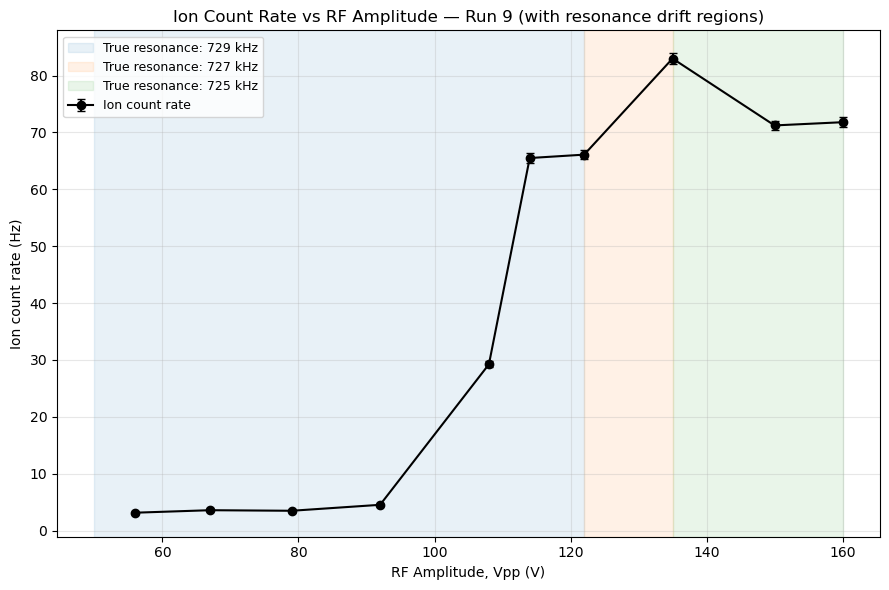

In [22]:
run9_df = rf_runs_df[rf_runs_df["run"] == 9]
plot_df = run9_df[run9_df["freq_khz"] == 729].copy().sort_values("vpp")

plt.figure(figsize=(9, 6))

# Shade the three regions where the true resonance frequency differed,
# even though all files are labeled 729 for parsing consistency
plt.axvspan(50, 122, color='tab:blue', alpha=0.1, label='True resonance: 729 kHz')
plt.axvspan(122, 135, color='tab:orange', alpha=0.1, label='True resonance: 727 kHz')
plt.axvspan(135, 160, color='tab:green', alpha=0.1, label='True resonance: 725 kHz')

plt.errorbar(
    plot_df["vpp"], plot_df["rate_hz"], yerr=plot_df["rate_unc_hz"],
    marker="o", capsize=3, color="black", label="Ion count rate"
)

plt.xlabel("RF Amplitude, Vpp (V)")
plt.ylabel("Ion count rate (Hz)")
plt.title("Ion Count Rate vs RF Amplitude — Run 9 (with resonance drift regions)")
plt.legend(fontsize=9)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
run9_df = rf_runs_df[rf_runs_df["run"] == 9]
run9_df

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz,config_label
118,RFPCB/RF56_729_9.mpa,56,729,9,3.137575,0.176782,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
119,RFPCB/RF67_729_9.mpa,67,729,9,3.576374,0.188754,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
120,RFPCB/RF79_729_9.mpa,79,729,9,3.476857,0.186112,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
121,RFPCB/RF92_729_9.mpa,92,729,9,4.525022,0.212370,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
122,RFPCB/RF108_729_9.mpa,108,729,9,29.228496,0.540250,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
123,RFPCB/RF114_729_9.mpa,114,729,9,65.492088,0.807867,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
124,RFPCB/RF122_729_9.mpa,122,729,9,66.085969,0.811558,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
125,RFPCB/RF135_729_9.mpa,135,729,9,82.983445,0.910807,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
126,RFPCB/RF150_729_9.mpa,150,729,9,71.222396,0.843415,"Resonant Frequency Test, Injection=10V (ΔV=6V)"
127,RFPCB/RF160_729_9.mpa,160,729,9,71.788979,0.846924,"Resonant Frequency Test, Injection=10V (ΔV=6V)"


In [24]:
vin_725_160 = 2.4 # 0.642 A
vin_725_150 = 2.2 # 0.578 A
vin_727_135 = 2.3 # 0.485 A
vin_729_122 = 2.3 # 0.358 A
vin_729_114 = 2.2 # 0.347 A
vin_729_108 = 2.1 # 0.319 A
vin_729_92 = 1.9 # 0.280 A
vin_729_79 = 1.7 # 0.242 A
vin_729_67 = 1.5 # 0.196 A
vin_729_56 = 1.9 # 0.162 A  

In [25]:
vin_data = [
    {"vpp": 56,  "true_freq_khz": 729, "vin": 1.5, "i": 0.162},
    {"vpp": 67,  "true_freq_khz": 729, "vin": 1.5, "i": 0.196},
    {"vpp": 79,  "true_freq_khz": 729, "vin": 1.7, "i": 0.242},
    {"vpp": 92,  "true_freq_khz": 729, "vin": 1.9, "i": 0.280},
    {"vpp": 108, "true_freq_khz": 729, "vin": 2.1, "i": 0.319},
    {"vpp": 114, "true_freq_khz": 729, "vin": 2.2, "i": 0.347},
    {"vpp": 122, "true_freq_khz": 729, "vin": 2.3, "i": 0.358},
    {"vpp": 135, "true_freq_khz": 727, "vin": 2.3, "i": 0.485},
    {"vpp": 150, "true_freq_khz": 725, "vin": 2.2, "i": 0.578},
    {"vpp": 160, "true_freq_khz": 725, "vin": 2.4, "i": 0.642},
]
vin_df = pd.DataFrame(vin_data)
vin_df["power_W"] = vin_df["vin"] * vin_df["i"]

run9_combined = run9_df.merge(vin_df, on="vpp", how="left").sort_values("vpp").reset_index(drop=True)
run9_combined

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz,config_label,true_freq_khz,vin,i,power_W
0,RFPCB/RF56_729_9.mpa,56,729,9,3.137575,0.176782,"Resonant Frequency Test, Injection=10V (ΔV=6V)",729,1.5,0.162,0.2430
1,RFPCB/RF67_729_9.mpa,67,729,9,3.576374,0.188754,"Resonant Frequency Test, Injection=10V (ΔV=6V)",729,1.5,0.196,0.2940
2,RFPCB/RF79_729_9.mpa,79,729,9,3.476857,0.186112,"Resonant Frequency Test, Injection=10V (ΔV=6V)",729,1.7,0.242,0.4114
3,RFPCB/RF92_729_9.mpa,92,729,9,4.525022,0.212370,"Resonant Frequency Test, Injection=10V (ΔV=6V)",729,1.9,0.280,0.5320
4,RFPCB/RF108_729_9.mpa,108,729,9,29.228496,0.540250,"Resonant Frequency Test, Injection=10V (ΔV=6V)",729,2.1,0.319,0.6699
5,RFPCB/RF114_729_9.mpa,114,729,9,65.492088,0.807867,"Resonant Frequency Test, Injection=10V (ΔV=6V)",729,2.2,0.347,0.7634
6,RFPCB/RF122_729_9.mpa,122,729,9,66.085969,0.811558,"Resonant Frequency Test, Injection=10V (ΔV=6V)",729,2.3,0.358,0.8234
7,RFPCB/RF135_729_9.mpa,135,729,9,82.983445,0.910807,"Resonant Frequency Test, Injection=10V (ΔV=6V)",727,2.3,0.485,1.1155
8,RFPCB/RF150_729_9.mpa,150,729,9,71.222396,0.843415,"Resonant Frequency Test, Injection=10V (ΔV=6V)",725,2.2,0.578,1.2716
9,RFPCB/RF160_729_9.mpa,160,729,9,71.788979,0.846924,"Resonant Frequency Test, Injection=10V (ΔV=6V)",725,2.4,0.642,1.5408


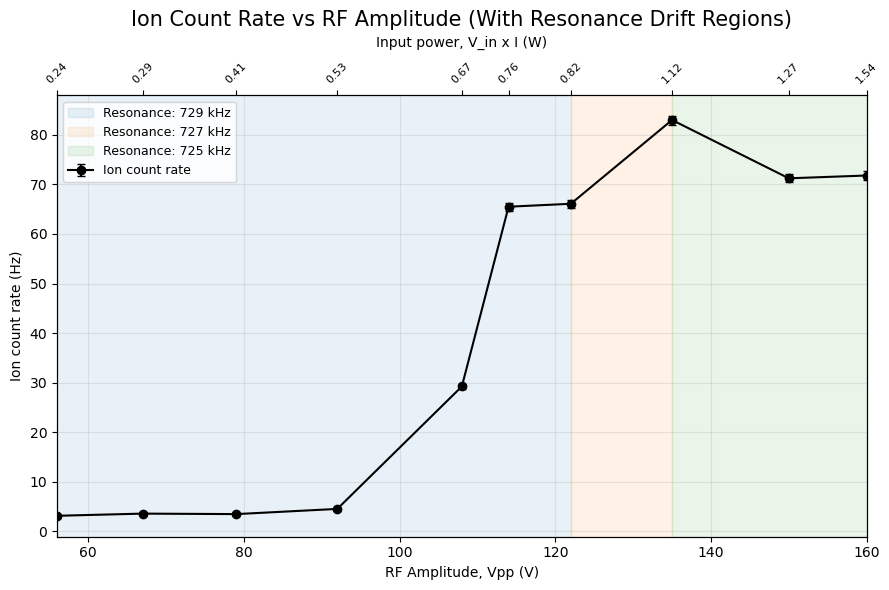

In [26]:
fig, ax1 = plt.subplots(figsize=(9, 6))

vpp_min = run9_combined["vpp"].min()
vpp_max = run9_combined["vpp"].max()

ax1.axvspan(vpp_min, 122, color='tab:blue', alpha=0.1, label='Resonance: 729 kHz')
ax1.axvspan(122, 135, color='tab:orange', alpha=0.1, label='Resonance: 727 kHz')
ax1.axvspan(135, vpp_max, color='tab:green', alpha=0.1, label='Resonance: 725 kHz')

ax1.errorbar(
    run9_combined["vpp"], run9_combined["rate_hz"], yerr=run9_combined["rate_unc_hz"],
    marker="o", capsize=3, color="black", label="Ion count rate"
)
ax1.set_xlim(vpp_min, vpp_max)  # trim to data range, no extra padding
ax1.set_xlabel("RF Amplitude, Vpp (V)")
ax1.set_ylabel("Ion count rate (Hz)")
ax1.set_title("Ion Count Rate vs RF Amplitude (With Resonance Drift Regions)", pad=50, fontsize = 15)
ax1.grid(True, which="both", alpha=0.3)

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(run9_combined["vpp"])
ax2.set_xticklabels([f"{p:.2f}" for p in run9_combined["power_W"]], rotation=45, fontsize=8)
ax2.set_xlabel("Input power, V_in x I (W)", labelpad=10)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

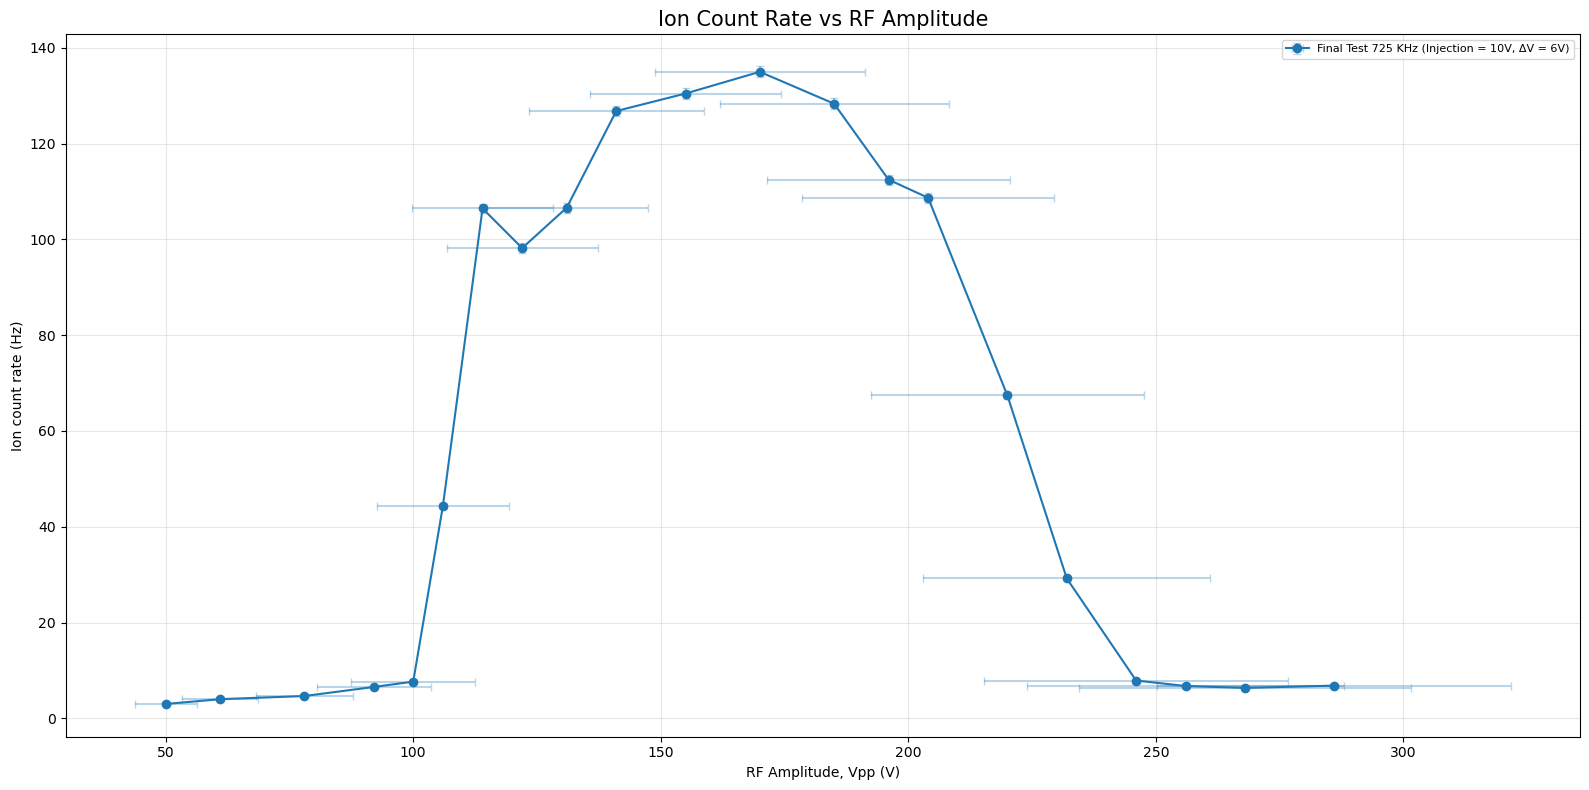

In [27]:
vpp_frac_err = 0.125  # established probe/divider systematic error

run_freq_map = {3: 722, 4: 722, 5: 722, 6: 722, 10: 725}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(16, 8))

for i, run_num in enumerate(runs_to_compare):  # excludes run 1
    freq_khz = run_freq_map[run_num]
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values("vpp")
    meta = run_config[run_num]
    color = colors[i % len(colors)]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    vpp_xerr = plot_df["vpp"] * vpp_frac_err

    plt.errorbar(
        plot_df["vpp"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=vpp_xerr,
        marker="o", capsize=3, color = color, ecolor=faded_color, label=meta["label"]
    )
plt.xlabel("RF Amplitude, Vpp (V)")
plt.ylabel("Ion count rate (Hz)")
plt.title("Ion Count Rate vs RF Amplitude", fontsize = 15)
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)


plt.tight_layout()
plt.show()

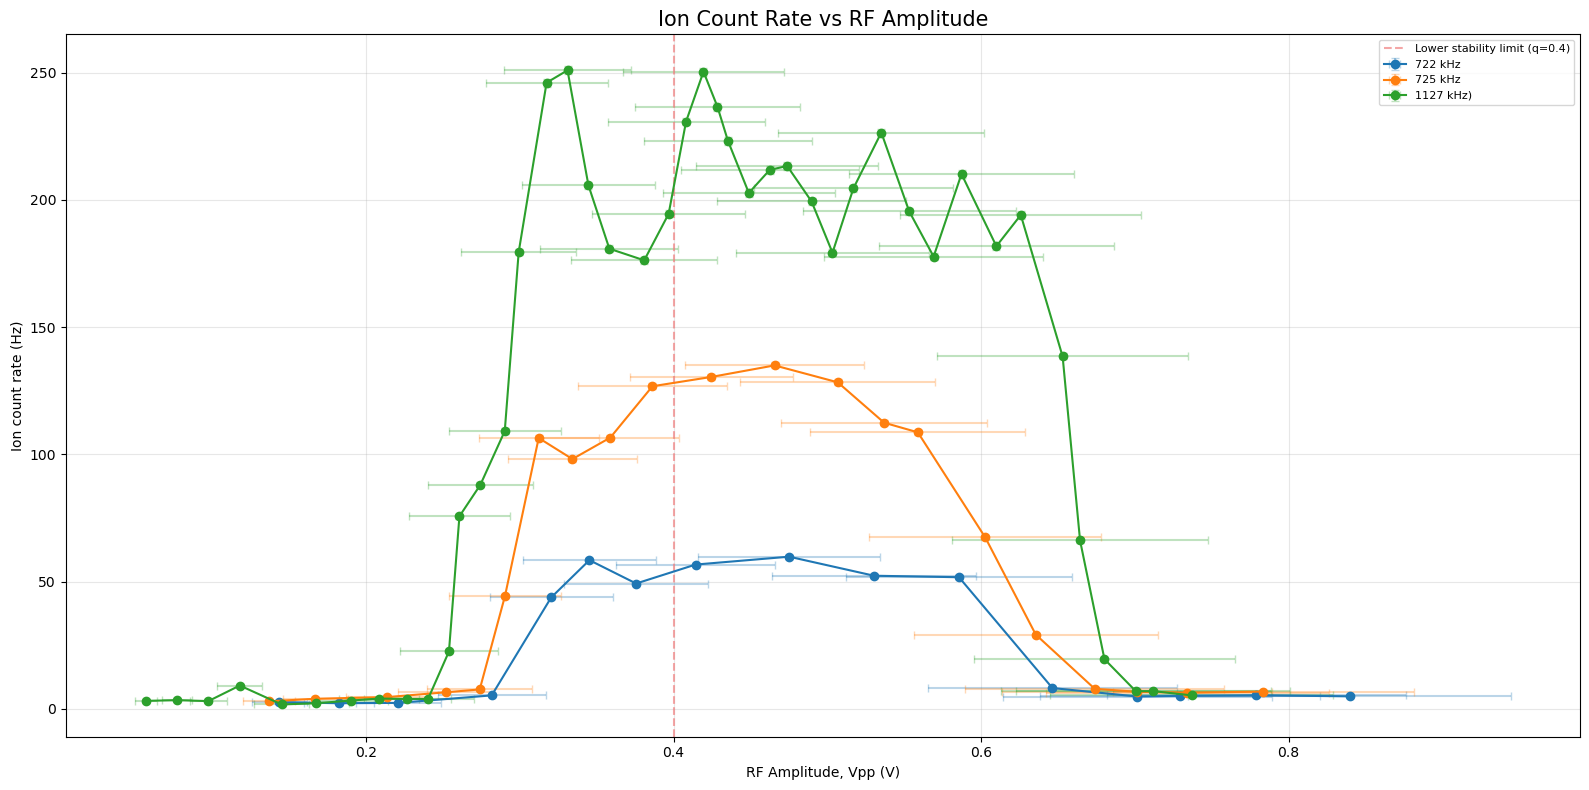

In [28]:
vpp_frac_err = 0.125  # established probe/divider systematic error

run_freq_map = {4: 722, 10: 725, 11: 1127}
labels = {4: "722 kHz", 10: "725 kHz", 11: "1127 kHz)"}

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(16, 8))

for i, run_num in enumerate(run_freq_map):  # excludes run 1
    freq_khz = run_freq_map[run_num]
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    meta = run_config[run_num]
    color = colors[i % len(colors)]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    q_xerr = plot_df["q"] * vpp_frac_err

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color = color, ecolor=faded_color, label = labels[run_num]
    )

plt.axvline(0.4, color='lightcoral', linestyle='--', alpha=0.7, label='Lower stability limit (q=0.4)')
plt.xlabel("RF Amplitude, Vpp (V)")
plt.ylabel("Ion count rate (Hz)")
plt.title("Ion Count Rate vs RF Amplitude", fontsize = 15)
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)


plt.tight_layout()
plt.show()

In [29]:
from scipy.signal import argrelextrema
import numpy as np

def find_local_dip_q(mass_u, run_df, r0_m, freq_khz, q_search_range=(0.3, 0.5)):
    """Finds the q-value of a local minimum in rate within a specified q window."""
    df = run_df[run_df["freq_khz"] == freq_khz].copy()
    df["q"] = df.apply(lambda row: q_val(mass_u, row["freq_khz"], r0_m, row["vpp"]), axis=1)
    df = df.sort_values("q").reset_index(drop=True)

    mask = (df["q"] >= q_search_range[0]) & (df["q"] <= q_search_range[1])
    windowed = df[mask].reset_index(drop=True)

    rate_arr = windowed["rate_hz"].values
    minima_idx = argrelextrema(rate_arr, np.less)[0]

    if len(minima_idx) == 0:
        return None
    q_dip = windowed["q"].iloc[minima_idx[np.argmin(rate_arr[minima_idx])]]
    return q_dip

for run_num, freq_khz in [(4, 722), (10, 725), (11, 1127)]:
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    q_dip = find_local_dip_q(cesium_mass, run_df, r_0, freq_khz)
    print(f"{freq_khz} kHz: local minimum at q = {q_dip}")

722 kHz: local minimum at q = 0.3756902722937229
725 kHz: local minimum at q = 0.3342329440314479
1127 kHz: local minimum at q = 0.38094026724840613


In [30]:
run_df = rf_runs_df[rf_runs_df["run"] == 10]
plot_df = run_df[run_df["freq_khz"] == 725]
print(plot_df[["vpp", "rate_hz", "rate_unc_hz"]])

     vpp     rate_hz  rate_unc_hz
97    50    2.998098     0.172807
98    61    3.995775     0.199539
99    78    4.654222     0.215372
100   92    6.543510     0.255481
101  100    7.654767     0.276398
102  106   44.385330     0.664991
103  114  106.446792     1.029878
104  122   98.170032     0.989448
105  131  106.601818     1.030751
106  141  126.776283     1.123984
107  155  130.437386     1.141031
108  170  134.966503     1.161693
109  185  128.313289     1.131183
110  196  112.454293     1.059947
111  204  108.670716     1.041116
112  220   67.395337     0.819824
113  232   29.191833     0.539849
114  246    7.895472     0.280731
115  256    6.743546     0.259367
116  268    6.353734     0.251744
117  286    6.824440     0.260939


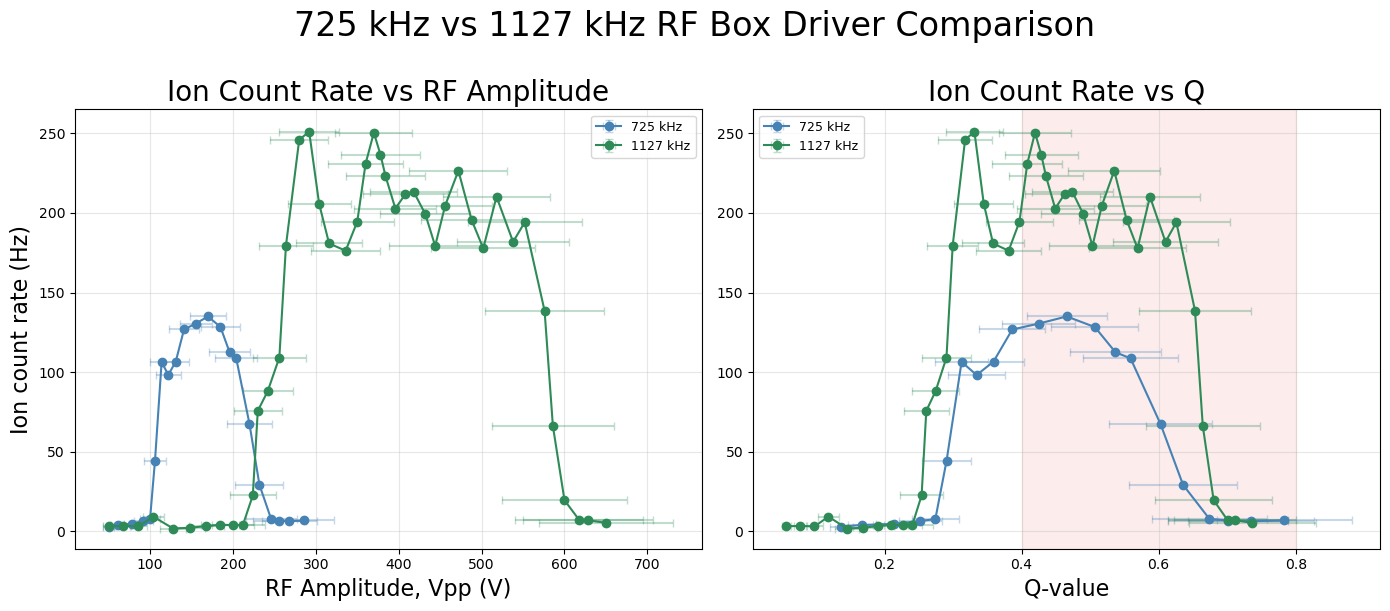

In [31]:
vpp_frac_err = 0.125

run_freq_map = {10: 725, 11: 1127}  # kHz, per run
freq_colors = {725: "steelblue", 1127: "seagreen"}

plt.figure(figsize=(14, 6))

# --- Left panel: Ion Count Rate vs Vpp ---
plt.subplot(1, 2, 1)
for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values("vpp")
    color = freq_colors[freq_khz]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    vpp_xerr = plot_df["vpp"] * vpp_frac_err

    plt.errorbar(
        plot_df["vpp"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=vpp_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=f"{freq_khz} kHz"
    )

plt.xlabel("RF Amplitude, Vpp (V)", fontsize = 16)
plt.ylabel("Ion count rate (Hz)", fontsize = 16)
plt.title("Ion Count Rate vs RF Amplitude", fontsize = 20)
plt.legend(fontsize=9)
plt.grid(True, which="both", alpha=0.3)

# --- Right panel: Ion Count Rate vs q-value (Cesium), with stability band ---
plt.subplot(1, 2, 2)
plt.axvspan(0.4, 0.8, color='lightcoral', alpha=0.15,)

for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    color = freq_colors[freq_khz]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    q_xerr = plot_df["q"] * vpp_frac_err

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=f"{freq_khz} kHz"
    )

plt.xlabel("Q-value", fontsize = 16)
plt.title("Ion Count Rate vs Q", fontsize = 20)
plt.suptitle("725 kHz vs 1127 kHz RF Box Driver Comparison", fontsize = 24, y=1.01)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
run11 = rf_runs_df[rf_runs_df["run"] == 11].copy()
run11

,filepath,vpp,freq_khz,run,rate_hz,rate_unc_hz,config_label
128,RFPCB/RF50_1127_11.mpa,50,1127,11,3.162618,0.176796,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
129,RFPCB/RF68_1127_11.mpa,68,1127,11,3.440470,0.185229,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
130,RFPCB/RF86_1127_11.mpa,86,1127,11,3.077659,0.175082,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
131,RFPCB/RF104_1127_11.mpa,104,1127,11,9.197583,0.303071,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
132,RFPCB/RF128_1127_11.mpa,128,1127,11,1.759701,0.132642,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
133,RFPCB/RF148_1127_11.mpa,148,1127,11,2.250256,0.149685,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
134,RFPCB/RF168_1127_11.mpa,168,1127,11,3.306411,0.181463,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
135,RFPCB/RF184_1127_11.mpa,184,1127,11,4.084723,0.201730,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
136,RFPCB/RF200_1127_11.mpa,200,1127,11,3.925828,0.197780,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"
137,RFPCB/RF212_1127_11.mpa,212,1127,11,3.926102,0.197794,"Final Test 1127 KHz (Injection = 10V, ΔV = 6V)"


In [33]:
def pseudopotential(mass_u, f_hz, vpp, r0_m, pot_eff=1.0):
    """
    Calculate the Mathieu q-value and pseudopotential well depth for a
    quadrupole RFQ.
    """
    e = 1.602176634e-19
    u = 1.66053906660e-27

    m_kg = mass_u * u
    omega = 2 * np.pi * f_hz
    q = 2 * e * vpp / (m_kg * r0_m**2 * omega**2)
    D = q * vpp / 8 * pot_eff
    return q, D

def min_pseudopotential_for_transmission(mass_u, run_df, r0_m, freq_khz, pot_eff=1.0):
    """
    Finds the Vpp at the rising-edge half-max crossing (same logic as the
    resolving-power FWHM calculation) and converts it to pseudopotential
    well depth D -- interpreted as the minimum well depth at which
    transmission becomes significant.
    """
    df = run_df[run_df["freq_khz"] == freq_khz].copy().sort_values("vpp").reset_index(drop=True)
    vpp_arr = df["vpp"].values
    rate_arr = df["rate_hz"].values

    peak_idx = np.argmax(rate_arr)
    half_max = rate_arr[peak_idx] / 2

    rising_vpp = vpp_arr[:peak_idx + 1]
    rising_rate = rate_arr[:peak_idx + 1]

    vpp_onset = np.interp(half_max, rising_rate, rising_vpp)

    q_onset, D_onset = pseudopotential(mass_u, freq_khz, vpp_onset, r0_m, pot_eff)

    return {
        "vpp_onset": vpp_onset,
        "q_onset": q_onset,
        "D_onset": D_onset,
    }

In [34]:
result_10 = min_pseudopotential_for_transmission(cesium_mass, rf_runs_df[rf_runs_df["run"]==10], r_0, 725)
result_11 = min_pseudopotential_for_transmission(cesium_mass, rf_runs_df[rf_runs_df["run"]==11], r_0, 1127)

print(f"Run 10 (725 kHz): Vpp_onset= {result_10['vpp_onset']:.1f}, D_onset= {result_10['D_onset']:.2f} V")
print(f"Run 11 (1127 kHz): Vpp_onset= {result_11['vpp_onset']:.1f}, D_onset= {result_11['D_onset']:.2f} V")#

Run 10 (725 kHz): Vpp_onset= 109.0, D_onset= 4.07 V
Run 11 (1127 kHz): Vpp_onset= 257.9, D_onset= 9.42 V


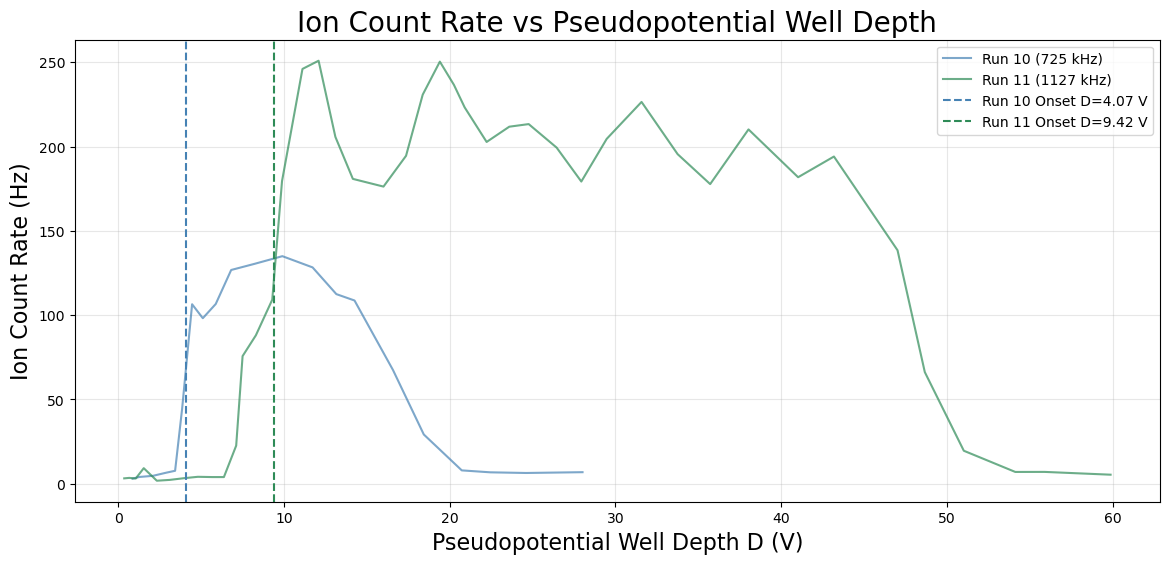

In [35]:
run10['pseudo'] = run10.apply(lambda row: pseudopotential(cesium_mass, row['freq_khz'], row['vpp'], r_0)[1], axis=1)
run11['pseudo'] = run11.apply(lambda row: pseudopotential(cesium_mass, row['freq_khz'], row['vpp'], r_0)[1], axis=1)

plt.figure(figsize=(14, 6))
plt.plot(run10['pseudo'], run10['rate_hz'], label='Run 10 (725 kHz)', color='steelblue', alpha=0.7)
plt.plot(run11['pseudo'], run11['rate_hz'], label='Run 11 (1127 kHz)', color='seagreen', alpha=0.7)
plt.xlabel('Pseudopotential Well Depth D (V)', fontsize=16)
plt.ylabel('Ion Count Rate (Hz)', fontsize=16)
plt.title('Ion Count Rate vs Pseudopotential Well Depth', fontsize=20)
plt.axvline(result_10['D_onset'], color='steelblue', linestyle='--', label=f'Run 10 Onset D={result_10["D_onset"]:.2f} V')
plt.axvline(result_11['D_onset'], color='seagreen', linestyle='--', label=f'Run 11 Onset D={result_11["D_onset"]:.2f} V')
plt.legend(fontsize=10)
plt.grid(True, which='both', alpha=0.3)
plt.show()

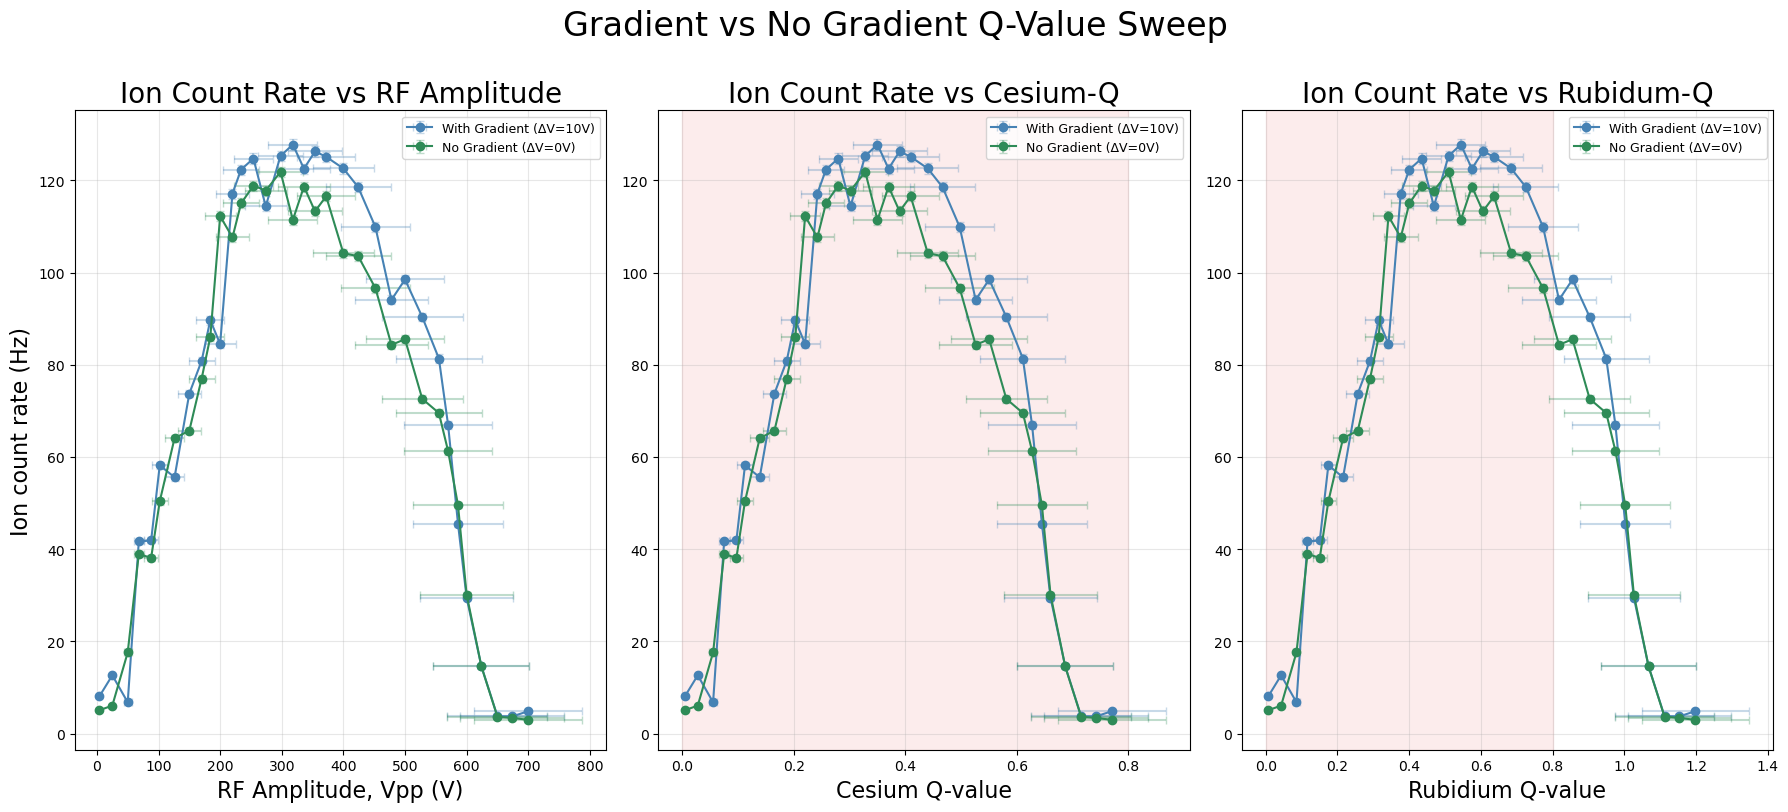

In [36]:
# DC Gradient vs Q-value
# With Gradient: 6V difference
# Without Gradient: 0V difference

# Operating at ~3.583e-03 mbar internal pressure (2.3e-6 Off, 6.3e-6 Gauge), Heating Power: 1.6758 W 

vpp_frac_err = 0.125

run_freq_map = {12: 1144, 13: 1144}  # kHz, per run
run_labels = {12: "With Gradient (ΔV=10V)", 13: "No Gradient (ΔV=0V)"}
run_colors = {12: "steelblue", 13: "seagreen"}

plt.figure(figsize=(18, 8))

# --- Left panel: Ion Count Rate vs Vpp ---
plt.subplot(1, 3, 1)
for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values("vpp")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    vpp_xerr = plot_df["vpp"] * vpp_frac_err

    plt.errorbar(
        plot_df["vpp"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=vpp_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )

plt.xlabel("RF Amplitude, Vpp (V)", fontsize=16)
plt.ylabel("Ion count rate (Hz)", fontsize=16)
plt.title("Ion Count Rate vs RF Amplitude", fontsize=20)
plt.legend(fontsize=9)
plt.grid(True, which="both", alpha=0.3)

# --- Right panel: Ion Count Rate vs q-value (Cesium), with stability band ---
plt.subplot(1, 3, 2)
plt.axvspan(0, 0.8, color='lightcoral', alpha=0.15)

for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    q_xerr = plot_df["q"] * vpp_frac_err

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )

plt.xlabel("Cesium Q-value", fontsize=16)
plt.title("Ion Count Rate vs Cesium-Q", fontsize=20)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1,3,3)
plt.axvspan(0, 0.8, color='lightcoral', alpha=0.15)
for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(rubidium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    q_xerr = plot_df["q"] * vpp_frac_err

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )

plt.xlabel("Rubidium Q-value", fontsize=16)
plt.title("Ion Count Rate vs Rubidum-Q", fontsize=20)
plt.suptitle("Gradient vs No Gradient Q-Value Sweep", fontsize=24, y=1.01)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

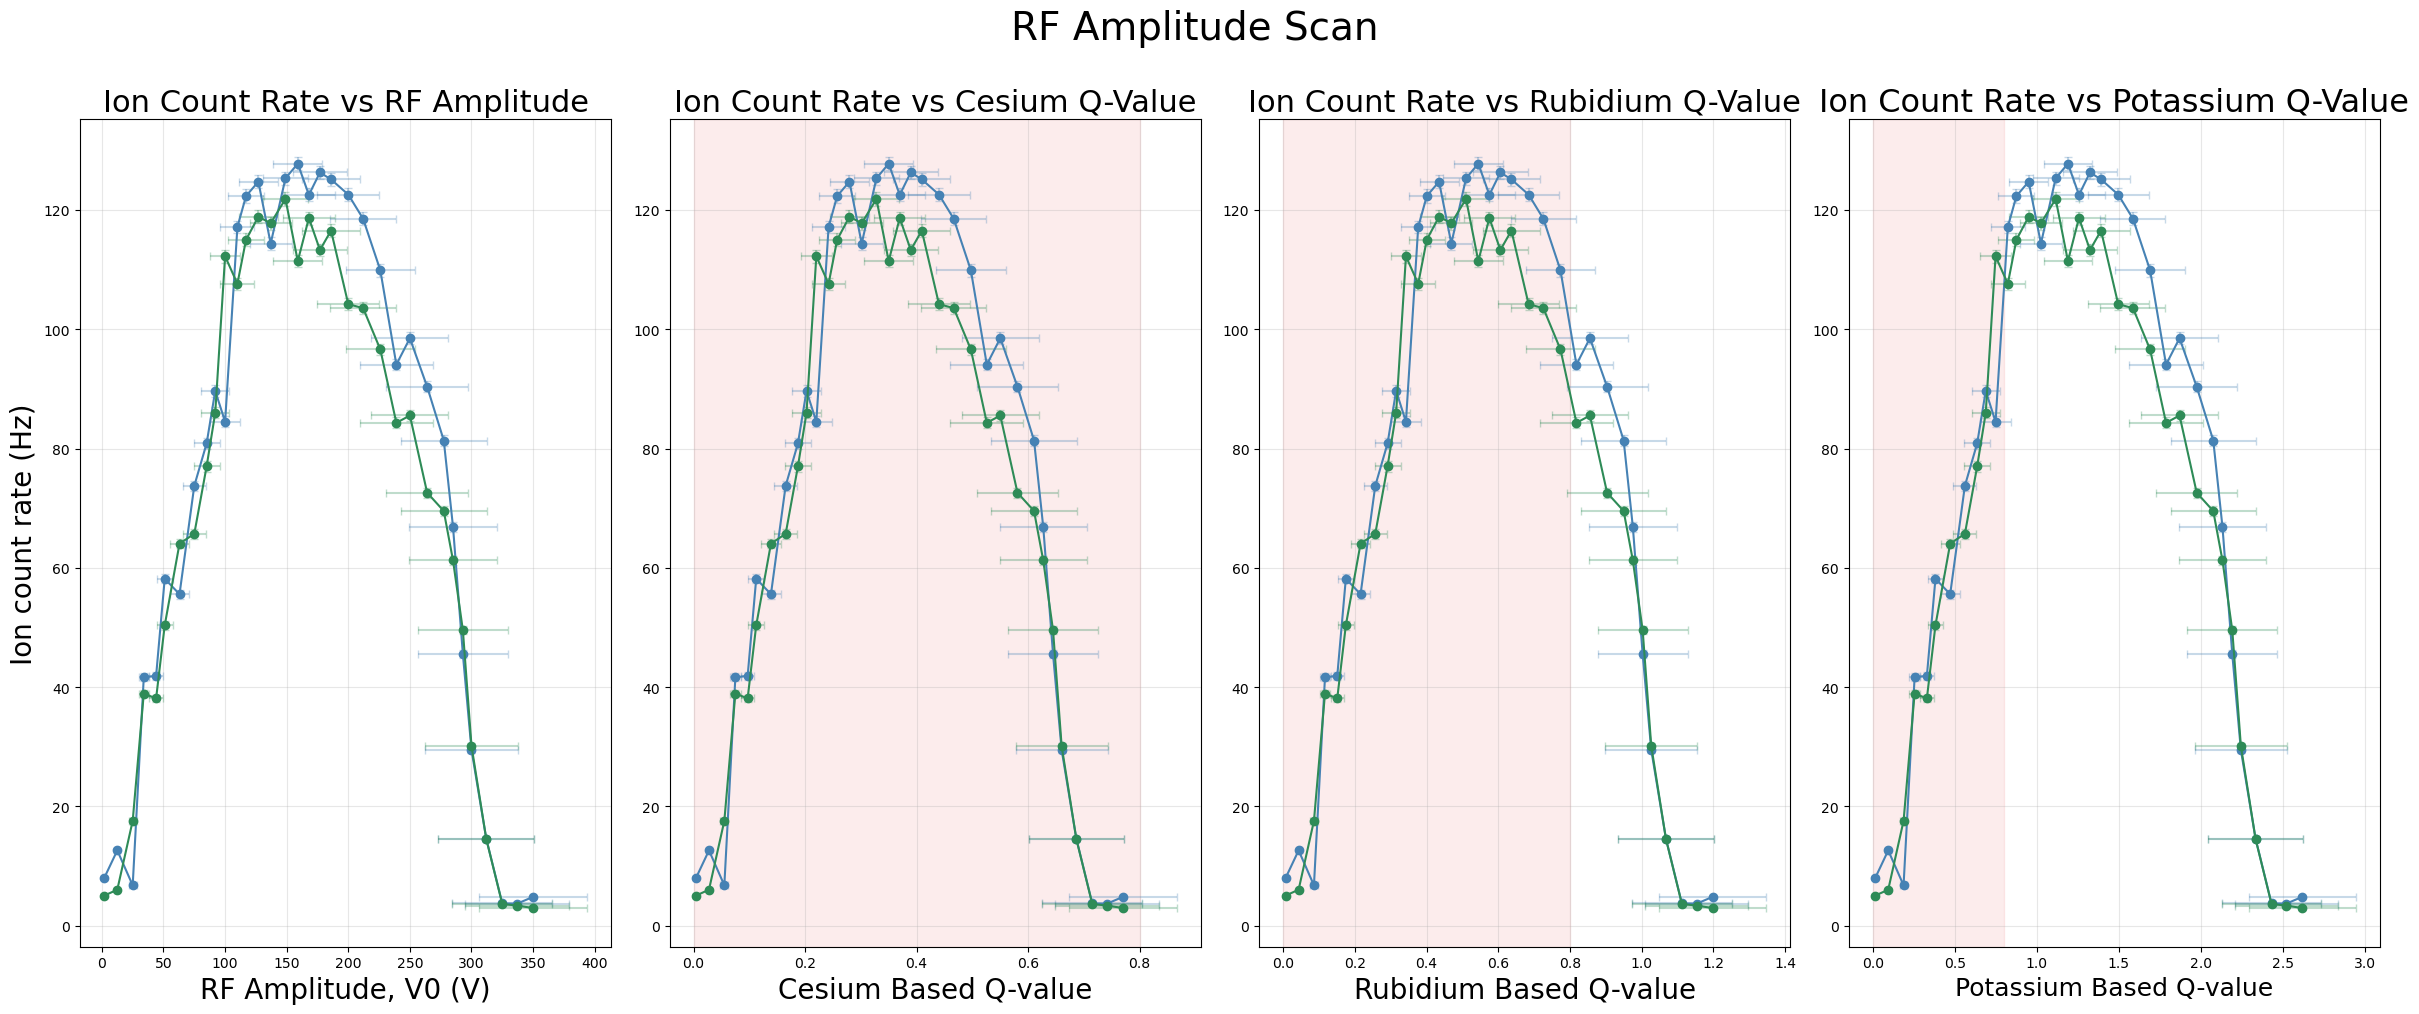

In [37]:
plt.figure(figsize=(24, 10))

# --- Panel 1: Ion Count Rate vs RF Amplitude (V0 = Vpp/2) ---
plt.subplot(1, 4, 1)
for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values("vpp")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    v0 = plot_df["vpp"] / 2
    v0_xerr = v0 * vpp_frac_err

    plt.errorbar(
        v0, plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=v0_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )

plt.xlabel("RF Amplitude, V0 (V)", fontsize=20)
plt.ylabel("Ion count rate (Hz)", fontsize=20)
plt.title("Ion Count Rate vs RF Amplitude", fontsize=22)
plt.grid(True, which="both", alpha=0.3)

# --- Panel 2: Cesium q-value (no /2 -- q_val already correct) ---
plt.subplot(1, 4, 2)
plt.axvspan(0, 0.8, color='lightcoral', alpha=0.15)
for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(cesium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)
    q_xerr = plot_df["q"] * vpp_frac_err

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )
plt.xlabel("Cesium Based Q-value", fontsize=20)
plt.title("Ion Count Rate vs Cesium Q-Value", fontsize=22)
plt.grid(True, alpha=0.3)

# --- Panel 3: Rubidium q-value (no /2) ---
plt.subplot(1, 4, 3)
plt.axvspan(0, 0.8, color='lightcoral', alpha=0.15)
for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(rubidium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)
    q_xerr = plot_df["q"] * vpp_frac_err

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )
plt.xlabel("Rubidium Based Q-value", fontsize=20)
plt.title("Ion Count Rate vs Rubidium Q-Value", fontsize=22)
plt.suptitle("RF Amplitude Scan", fontsize=28, y=1.01)
plt.grid(True, alpha=0.3)

# --- Panel 4: Potassium q-value (already correct, unchanged) ---
plt.subplot(1, 4, 4)
plt.axvspan(0, 0.8, color='lightcoral', alpha=0.15)
for run_num, freq_khz in run_freq_map.items():
    run_df = rf_runs_df[rf_runs_df["run"] == run_num]
    plot_df = run_df[run_df["freq_khz"] == freq_khz].copy()
    if plot_df.empty:
        continue
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(potassium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)
    q_xerr = plot_df["q"] * vpp_frac_err

    plt.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )
plt.xlabel("Potassium Based Q-value", fontsize=18)
plt.title("Ion Count Rate vs Potassium Q-Value", fontsize=23)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 3.8

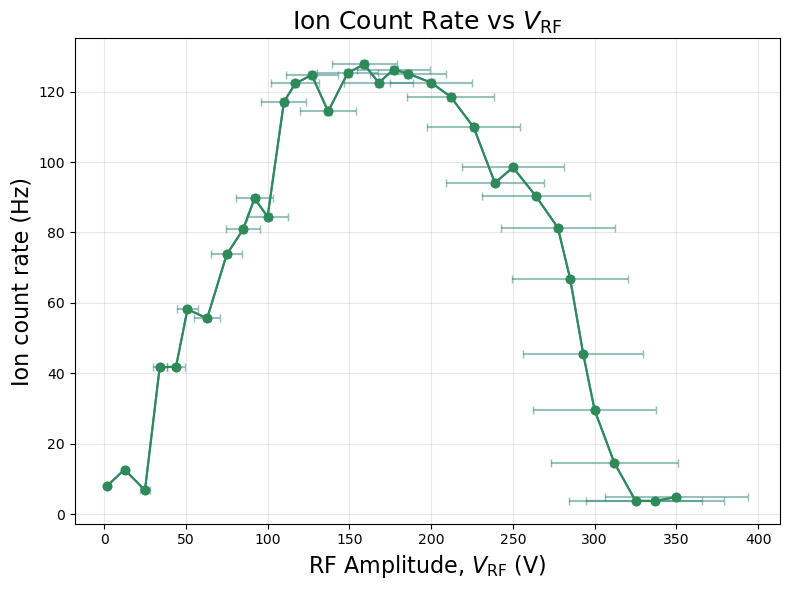

In [38]:
plt.figure(figsize=(8, 6))
run12 = rf_runs_df[rf_runs_df["run"] == 12].copy()

for run_num, freq_khz in run_freq_map.items():
    plot_df = run12

    plot_df = plot_df.sort_values("vpp")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)

    v_rf = plot_df["vpp"] / 2
    v_rf_xerr = v_rf * vpp_frac_err

    plt.errorbar(
        v_rf, plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=v_rf_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )

plt.xlabel(r"RF Amplitude, $V_{\mathrm{RF}}$ (V)", fontsize=16)
plt.ylabel("Ion count rate (Hz)", fontsize=16)
plt.title(r"Ion Count Rate vs $V_{\mathrm{RF}}$", fontsize=18)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

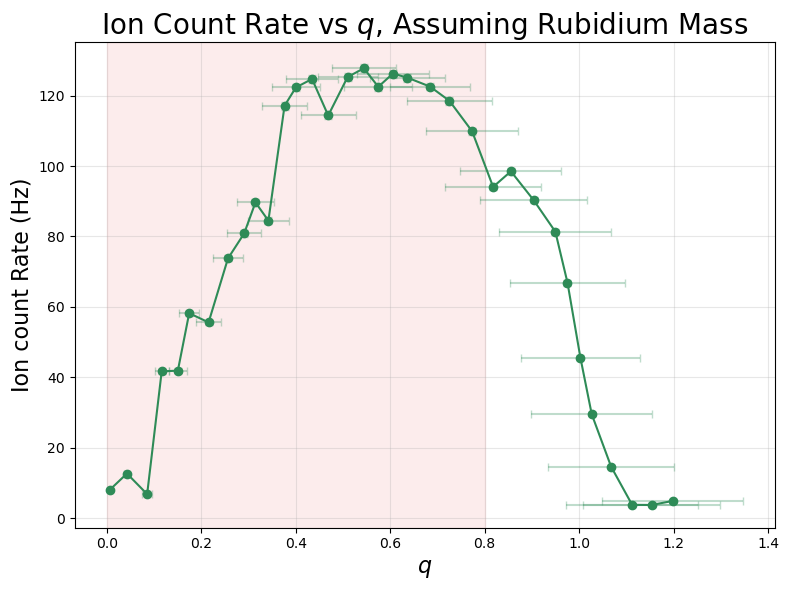

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

mass, name = rubidium_mass, "Rubidium"

ax.axvspan(0, 0.8, color='lightcoral', alpha=0.15)

plot_df = run12
plot_df["q"] = plot_df.apply(
    lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]), axis=1
)
plot_df = plot_df.sort_values("q")

color = run_colors[run_num]
faded_color = mcolors.to_rgba(color, alpha=0.3)
q_xerr = plot_df["q"] * vpp_frac_err

ax.errorbar(
    plot_df["q"], plot_df["rate_hz"],
    yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
    marker="o", capsize=3, color=color, ecolor=faded_color,
    label=run_labels[run_num]
)

ax.set_xlabel(f"$q$", fontsize=16)
ax.set_title(f"Ion Count Rate vs $q$, Assuming {name} Mass", fontsize=20)
ax.set_ylabel("Ion count Rate (Hz)", fontsize=16)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

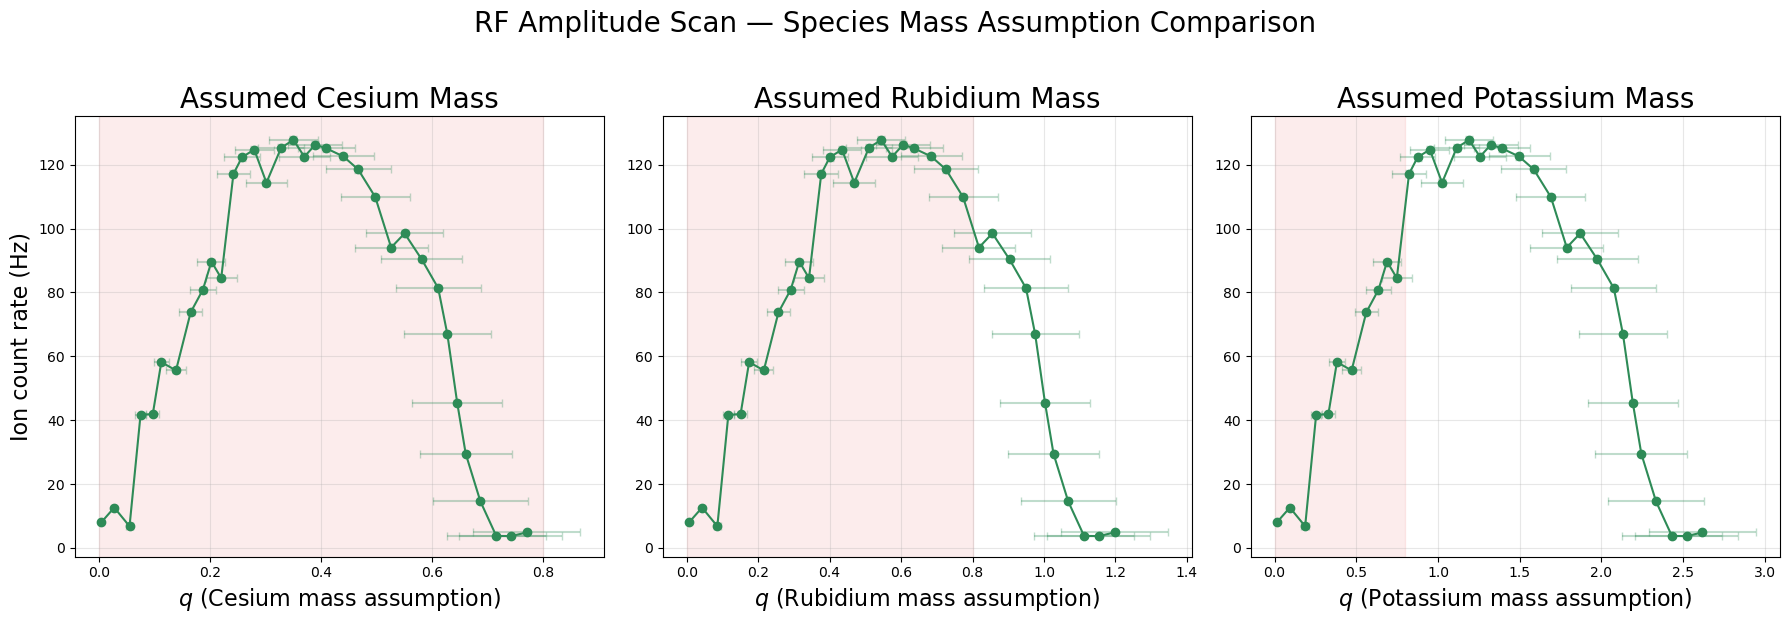

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

species_configs = [
    (cesium_mass, "Cesium"),
    (rubidium_mass, "Rubidium"),
    (potassium_mass, "Potassium"),
]

for ax, (mass, name) in zip(axes, species_configs):
    ax.axvspan(0, 0.8, color='lightcoral', alpha=0.15)
    plot_df = run12
    plot_df["q"] = plot_df.apply(
        lambda row: q_val(mass, row["freq_khz"], r_0, row["vpp"]), axis=1
    )
    plot_df = plot_df.sort_values("q")
    color = run_colors[run_num]
    faded_color = mcolors.to_rgba(color, alpha=0.3)
    q_xerr = plot_df["q"] * vpp_frac_err

    ax.errorbar(
        plot_df["q"], plot_df["rate_hz"],
        yerr=plot_df["rate_unc_hz"], xerr=q_xerr,
        marker="o", capsize=3, color=color, ecolor=faded_color,
        label=run_labels[run_num]
    )
    ax.set_xlabel(f"$q$ ({name} mass assumption)", fontsize=16)
    ax.set_title(f"Assumed {name} Mass", fontsize=20)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Ion count rate (Hz)", fontsize=16)
fig.suptitle("RF Amplitude Scan — Species Mass Assumption Comparison", fontsize=20, y=1.03)
plt.tight_layout()
plt.show()

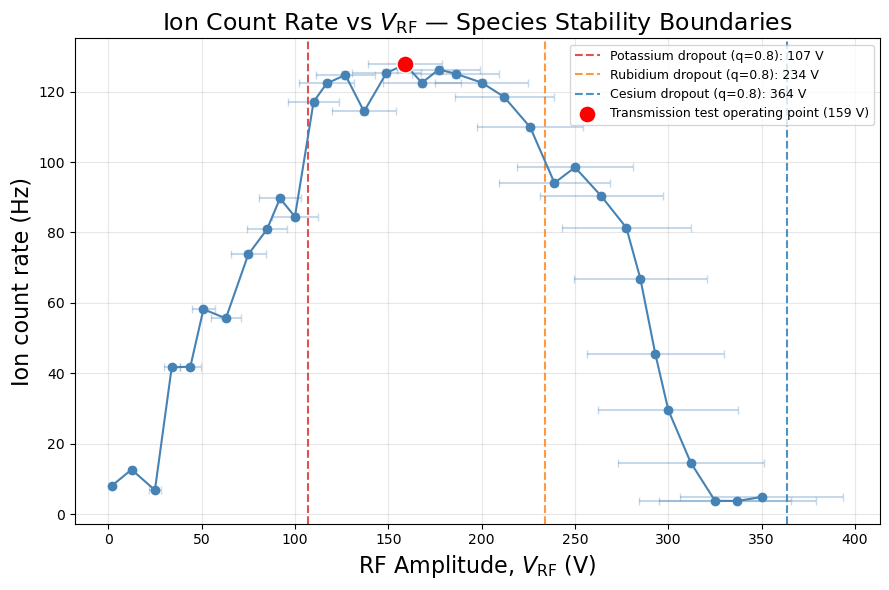

In [46]:
def vrf_for_q(mass_u, f_hz, q_target, r0_m, pot_eff=1.0):
    """Inverse of q_val: given a target q, find the V_RF (zero-to-peak) that produces it."""
    e = 1.602176634e-19
    u = 1.66053906660e-27
    m_kg = mass_u * u
    omega = 2 * np.pi * f_hz
    v_rf = q_target * m_kg * r0_m**2 * omega**2 / (4*e)
    return v_rf

freq_khz = 1144
operating_v_rf = 155  # V_RF used for transmission tests

species_boundaries = {
    "Potassium": {"mass": potassium_mass, "color": "tab:red"},
    "Rubidium": {"mass": rubidium_mass, "color": "tab:orange"},
    "Cesium": {"mass": cesium_mass, "color": "tab:blue"},
}

for name, cfg in species_boundaries.items():
    cfg["v_rf_boundary"] = vrf_for_q(cfg["mass"], freq_khz*1000, 0.8, r_0/1000)

plt.figure(figsize=(9, 6))

run_num = 12
run_df = rf_runs_df[rf_runs_df["run"] == run_num]
plot_df = run_df[run_df["freq_khz"] == freq_khz].copy().sort_values("vpp")
color = run_colors[run_num]
faded_color = mcolors.to_rgba(color, alpha=0.3)

v_rf = plot_df["vpp"] / 2
v_rf_xerr = v_rf * vpp_frac_err

plt.errorbar(
    v_rf, plot_df["rate_hz"],
    yerr=plot_df["rate_unc_hz"], xerr=v_rf_xerr,
    marker="o", capsize=3, color=color, ecolor=faded_color, zorder=5
)

for name, cfg in species_boundaries.items():
    plt.axvline(cfg["v_rf_boundary"], color=cfg["color"], linestyle="--", alpha=0.8,
                label=f"{name} dropout (q=0.8): {cfg['v_rf_boundary']:.0f} V")

# Highlight the closest actual data point to the operating V_RF
closest_idx = (v_rf - operating_v_rf).abs().idxmin()
plt.scatter(v_rf.loc[closest_idx], plot_df.loc[closest_idx, "rate_hz"],
            marker="o", s=150, color="red", edgecolor="white", linewidth=1, zorder=6,
            label=f"Transmission test operating point ({v_rf.loc[closest_idx]:.0f} V)")

plt.xlabel(r"RF Amplitude, $V_{\mathrm{RF}}$ (V)", fontsize=16)
plt.ylabel("Ion count rate (Hz)", fontsize=16)
plt.title(r"Ion Count Rate vs $V_{\mathrm{RF}}$ — Species Stability Boundaries", fontsize=17)
plt.legend(fontsize=9)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
import os
import shutil

def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)

def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw/, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)

    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)

    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing

In [53]:
description = [
    "Ion Count Rate vs. RF Amplitude (V_RF) and Mathieu q-value",
    "Corresponds to Figures 3.8 and 3.9",
    "",
    "Purpose: characterizes radial (transverse) ion confinement provided by",
    "the RFQ's RF field, following axial confinement characterization",
    "(Figure 3.7). RF amplitude directly sets the strength of the radial",
    "confining pseudopotential; too little confinement loses ions radially,",
    "while too much can destabilize ion motion via collisional RF heating.",
    "1144 kHz was selected as the drive frequency after testing several",
    "alternatives (Section 3.4.3).",
    "",
    "The Mathieu q-value reinterprets the same scan in terms of the",
    "dimensionless stability parameter that actually governs confinement,",
    "computed assuming a rubidium mass (the working assumption for the",
    "dominant species in the mixed alkali source), via",
    "q = 2*e*Vpp / (m * r0^2 * Omega^2).",
    "",
    "V_RF carries a systematic uncertainty of ~12.5% from probe and",
    "voltage-divider calibration on the driver box, applied as a single",
    "shared offset across all points from a given run; this propagates",
    "directly into the q uncertainty.",
    "",
    "Columns:",
    "  v_rf_volts    - RF amplitude, zero-to-peak (V) = Vpp/2",
    "  v_rf_err_volts- Uncertainty on V_RF (12.5% probe/divider systematic)",
    "  q             - Mathieu q-value (rubidium mass assumption)",
    "  q_err         - Uncertainty on q (from the same 12.5% systematic)",
    "  rate_hz       - Ion count rate (Hz)",
    "  rate_unc_hz   - Ion count rate uncertainty (Hz)",
    "  file          - Source .mpa filename",
]

run12 = rf_runs_df[rf_runs_df["run"] == 12].copy().sort_values("vpp")

run12["v_rf"] = run12["vpp"] / 2
run12["v_rf_err"] = run12["v_rf"] * vpp_frac_err
run12["q"] = run12.apply(lambda row: q_val(rubidium_mass, row["freq_khz"], r_0, row["vpp"]), axis=1)
run12["q_err"] = run12["q"] * vpp_frac_err

export_cols_map = {
    "v_rf": "v_rf_volts",
    "v_rf_err": "v_rf_err_volts",
    "q": "q",
    "q_err": "q_err",
    "rate_hz": "rate_hz",
    "rate_unc_hz": "rate_unc_hz",
    "filepath": "file",
}

export_df = run12[list(export_cols_map.keys())].rename(columns=export_cols_map)
export_df = export_df.sort_values("v_rf_volts").reset_index(drop=True)

export_figure_csv(export_df, "thesis/rf_amplitude_and_q_value.csv", description)
print(export_df)

archive_raw_files(export_df["file"].str.split("/").str[-1].tolist(), "RFPCB", "rf_amplitude_and_q_value")

    v_rf_volts  v_rf_err_volts         q     q_err     rate_hz  rate_unc_hz  \
0          2.0          0.2500  0.006844  0.000856    8.056565     0.283254   
1         12.5          1.5625  0.042775  0.005347   12.634100     0.355081   
2         25.0          3.1250  0.085551  0.010694    6.783787     0.260146   
3         34.0          4.2500  0.116349  0.014544   41.655840     0.645226   
4         44.0          5.5000  0.150569  0.018821   41.876968     0.646946   
5         51.0          6.3750  0.174523  0.021815   58.187913     0.761946   
6         63.0          7.8750  0.215588  0.026948   55.578809     0.744233   
7         75.0          9.3750  0.256652  0.032082   73.756945     0.856944   
8         85.0         10.6250  0.290872  0.036359   80.850851     0.898565   
9         92.0         11.5000  0.314827  0.039353   89.661436     0.946008   
10       100.0         12.5000  0.342203  0.042775   84.487824     0.917317   
11       110.0         13.7500  0.376423  0.047053  

(['RF4_1144_12.mpa',
  'RF25_1144_12.mpa',
  'RF50_1144_12.mpa',
  'RF68_1144_12.mpa',
  'RF88_1144_12.mpa',
  'RF102_1144_12.mpa',
  'RF126_1144_12.mpa',
  'RF150_1144_12.mpa',
  'RF170_1144_12.mpa',
  'RF184_1144_12.mpa',
  'RF200_1144_12.mpa',
  'RF220_1144_12.mpa',
  'RF234_1144_12.mpa',
  'RF254_1144_12.mpa',
  'RF274_1144_12.mpa',
  'RF298_1144_12.mpa',
  'RF318_1144_12.mpa',
  'RF336_1144_12.mpa',
  'RF354_1144_12.mpa',
  'RF372_1144_12.mpa',
  'RF400_1144_12.mpa',
  'RF424_1144_12.mpa',
  'RF452_1144_12.mpa',
  'RF478_1144_12.mpa',
  'RF500_1144_12.mpa',
  'RF528_1144_12.mpa',
  'RF555_1144_12.mpa',
  'RF570_1144_12.mpa',
  'RF586_1144_12.mpa',
  'RF600_1144_12.mpa',
  'RF624_1144_12.mpa',
  'RF650_1144_12.mpa',
  'RF674_1144_12.mpa',
  'RF700_1144_12.mpa'],
 [])

In [54]:
description = [
    "Ion Count Rate vs. RF Amplitude, with Species Stability Boundaries",
    "Presentation figure (not a numbered dissertation figure)",
    "",
    "Purpose: same RF amplitude scan as Figures 3.8/3.9, annotated with the",
    "predicted q=0.8 stability dropout voltage for each candidate source",
    "species (potassium, rubidium, cesium), computed by inverting the Mathieu",
    "q relation for each species' mass at the same RF frequency (1144 kHz).",
    "This shows where each species would be expected to destabilize and lose",
    "confinement, and highlights the actual RF amplitude used for the",
    "transmission efficiency measurements (~155 V_RF).",
    "",
    "Columns:",
    "  v_rf_volts     - RF amplitude, zero-to-peak (V), measured scan point",
    "  v_rf_err_volts - Uncertainty on V_RF (12.5% probe/divider systematic)",
    "  rate_hz        - Ion count rate (Hz)",
    "  rate_unc_hz    - Ion count rate uncertainty (Hz)",
    "  file           - Source .mpa filename",
    "",
    "Derived species stability boundaries (q=0.8 dropout point, at 1144 kHz):",
    f"  Potassium: {species_boundaries['Potassium']['v_rf_boundary']:.1f} V",
    f"  Rubidium:  {species_boundaries['Rubidium']['v_rf_boundary']:.1f} V",
    f"  Cesium:    {species_boundaries['Cesium']['v_rf_boundary']:.1f} V",
    "  Operating point used for transmission tests: ~155 V",
]

export_df_pres = run12[["v_rf", "v_rf_err", "rate_hz", "rate_unc_hz", "filepath"]].rename(
    columns={"v_rf": "v_rf_volts", "v_rf_err": "v_rf_err_volts", "filepath": "file"}
).sort_values("v_rf_volts").reset_index(drop=True)

export_figure_csv(export_df_pres, "thesis/rf_amplitude_species_boundaries.csv", description)
print(export_df_pres)

    v_rf_volts  v_rf_err_volts     rate_hz  rate_unc_hz  \
0          2.0          0.2500    8.056565     0.283254   
1         12.5          1.5625   12.634100     0.355081   
2         25.0          3.1250    6.783787     0.260146   
3         34.0          4.2500   41.655840     0.645226   
4         44.0          5.5000   41.876968     0.646946   
5         51.0          6.3750   58.187913     0.761946   
6         63.0          7.8750   55.578809     0.744233   
7         75.0          9.3750   73.756945     0.856944   
8         85.0         10.6250   80.850851     0.898565   
9         92.0         11.5000   89.661436     0.946008   
10       100.0         12.5000   84.487824     0.917317   
11       110.0         13.7500  117.136464     1.081680   
12       117.0         14.6250  122.328336     1.104300   
13       127.0         15.8750  124.734337     1.115613   
14       137.0         17.1250  114.360959     1.068095   
15       149.0         18.6250  125.300652     1.118266 